<div style="background: linear-gradient(135deg,  #8ab7f1 0%, #07376e 50%, #000000 100%);
            padding: 10px; border-radius: 8px; margin: 10px 0; color: black; font-family: Arial, sans-serif; text-align: center; font-size: 24px;">

# **Data preparations**
</div>

<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 20px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
        Данный ноутбук посвящён первичной обработке и подготовке данных для последующего разведочного анализа.

Исходные данные представляют собой сырую выборку по объектам недвижимости, содержащую:
- разноформатные признаки (строки, числа, словари);
- дублирующиеся или синонимичные поля;
- пропущенные и неструктурированные значения;
- геокодированную информацию в сжатом виде.

Такая структура затрудняет анализ и дальнейшее моделирование, поэтому первоочередная цель — привести данные к единому, аналитически удобному виду.

Цели предварительной обработки:
- Унификация форматов — приведение всех признаков к согласованным типам и единицам измерения.
- Структуризация — распаковка вложенных структур в отдельные колонки.
- Обогащение данных — извлечение новых информативных признаков из существующих полей.
      </div>
    </td>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/DP.jpg" alt="Карта штатов США" style="width: 100%; max-width: 500px;">
    </td>
  </tr>
</table>

</div>
</div>

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">ИМПОРТ</strong>
</div>

In [6]:
import re

import numpy as np
import pandas as pd
import ast
import json
import time


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from tqdm import tqdm
import requests


from math import log

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">ФУНКЦИИ</strong>
</div>

In [7]:
def graph_null(data, cmap_1 = "#60a5fa"):
    """
    Проверка нулевых/пустых значений в данных

    Аргументы:
    data - DataFrame с данными для анализа,
    cmap_1 - цветовая палитра.
    """
    # Строим диаграмму
    plt.figure(figsize=(17, 7))

    total_missing = data.isnull().sum().sum()
    columns_missing = data.isnull().sum()


    ax = sns.heatmap(
        data.isnull(),
        cbar=False,
        cmap=[cmap_1, "#0B2F41"],
        yticklabels=False
    )

    for i, col in enumerate(data.columns):
        missing = columns_missing[col]
        missing_percent = (missing / len(data)) * 100

    # Добавляем текст под названием признака
        ax.text(
            i + 0.5,
            -0.5,
            f"{missing_percent:.1f}%",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='#1e40af' if missing > 0 else '#666666'
        )

    # Расчет общего процента пропусков
    total_percent = (total_missing / data.size) * 100

    plt.title(
        f'Всего пропусков: {total_missing} шт ({total_percent:.1f}% от всех данных) | '
        f'Столбцы с пропусками: {sum(columns_missing > 0)}/{len(data.columns)}',
        pad=20,
        fontsize=15,
        loc='left'
    )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [8]:
def analize_feature(column, color_discrete_sequence=["#1580fb"], print_c1="44", print_c2="94"):
    """
    Построение графика признака, с показанием уникальных значений,
    их количества, выводом количества пропущенных значений, и топ-20 часто встречаемых признаков

    Аргументы:
        column (str): колонка датасета
        color_discrete_sequence (list): список цветов для графика
        print_c1 (str): код цвета для заголовков (фон)
        print_c2 (str): код цвета для текста
    """
    # Строим диаграмму
    fig = px.bar(
        df[column].value_counts().head(30).reset_index(),
        x='index',
        y=column,
        width=1200,
        height=700,
        color_discrete_sequence=color_discrete_sequence
    )


    # Настройка осей графика:
    fig.update_layout(
        title={
            'text': f"График признака {column}",
            'font': {'size': 24},
            'x' : .5
        },
        xaxis={
            'title': {
                'text': 'Уникальный показатель ',
                'font': {'size': 20}
            },
            'tickfont': {'size': 13}
        },
        yaxis={
            'title': {
                'text': 'Количество, шт',
                'font': {'size': 20}
            },
            'tickfont': {'size': 13},
        },
        margin=dict(l=40, r=40, t=40, b=40),
    )

    # Настройка информации при наведении курсора:
    fig.update_traces(
        hovertemplate="Количество: %{y} шт",
        marker_line_color='black',
        marker_line_width=2.5,
        opacity=0.75
    )

    fig.show()


    # Вывод статистики по уникальным значениям
    unique = df[column].value_counts().count()
    uni_txt = 'Количество уникальных показателей'
    print(f"\033[{print_c1}m\033[97m{uni_txt}:\033[0m\033[{print_c2}m {unique} шт\033[0m")


    # Вывод статистики по пропущенным значениям
    null = df[column].isnull().sum()
    total = len(df[column])
    percent = (null/total)*100
    null_txt = 'Количество пустых значений'
    print(f"\033[{print_c1}m\033[97m{null_txt}:\033[0m\033[{print_c2}m {null} шт, ({percent:.1f}%)\033[0m")

    # Вывод топ-20 самых частых значений
    more_often = df[column].value_counts().head(20).index.to_list()
    uni_txt = 'Топ встречаемых показателей'
    print(f"\033[{print_c1}m\033[97m{uni_txt}:\033[0m\033[0m")
    for i, value in enumerate(more_often, 1):
        print(f"\033[{print_c2}m  {i:2d}. {value}\033[0m")

In [9]:
def categorize_value(value, groups, default_category='Other'):
    """
    Функции по преобразованию признака с большим количеством переменных по группам

    Аргументы:
        value (str): значение для категоризации
        groups (str): словарь с категориями и списками ключевых слов
        default_category (str): категория по умолчанию если не найдено совпадение

    Вывод:
        Колонка с признакмами
    """

    if pd.isna(value) or value == '' or value == ' ':
        return np.nan

    value_str = str(value).strip()
    value_lower = value_str.lower()

    for category, keywords in groups.items():
        for keyword in keywords:
            if keyword.lower() in value_lower:
                return category

    return default_category

In [10]:
def cheсk_sample(dataframe, column_1, column_2):
    """ Проверка коррекции использования функций по редактированию колонки

    Аргументы:
        column1 (str): До редакции колонка
        column_2 (str): После редакции
        dataframe - датафрейм
    """
    # Проверим корректно ли мы функцию использовали
    sample = dataframe[[column_2, column_1]].sample(n=20)
    print(sample.to_string(index=False))

In [11]:
def extract_letters(dataframe, column_name):
    """
    Извлекает только буквы из указанной колонки и возвращает список уникальных значений с количеством

    Аргументы:
        column_name (str): Название колонки для обработки
        dataframe: Датафрейм

    Вывод:
        list: Список кортежей (значение, количество) после обработки
    """
    # Применяем функцию извлечения букв к колонке
    result = dataframe[column_name].apply(lambda text:
        re.sub(r'[^a-zA-Z\s]', '', str(text)).strip()
        if not pd.isna(text) else ""
    )

    value_counts = result.value_counts()

    print(f"Уникальные текстовые значения из {column_name}:")
    for i, (val, count) in enumerate(value_counts.items()):
        print(f"{i+1:2d}. '{val}' - {count} шт")

<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="font-weight: bold; color: #000000; margin-bottom: 10px;">
Drop list, куда соберем остаточные колонки, которые необходимо будет удалять по окончанию анализа:

In [12]:
drop_list = []

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАТАСЕТА</strong>
</div>

In [13]:
data  = pd.read_csv('data/data.csv')
# Чтобы делов всяких не наделать с датасетом начальным выполним его копию
df = data.copy()
df

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377180,NaN,NaN,Single Family,20800 NE 23rd Ave,6.0,"{'atAGlanceFacts': [{'factValue': '1990', 'fac...",NaN,Miami,"[{'rating': ['10/10', '5/10'], 'data': {'Dista...","4,017",33180,5,FL,0.0,NaN,Yes,A10702700,"$1,249,000"
377181,for sale,NaN,condo,3530 N Lake Shore Dr #4B,3 Baths,"{'atAGlanceFacts': [{'factValue': '1924', 'fac...",NaN,Chicago,"[{'rating': ['1/10', '5/10', '7/10'], 'data': ...","2,000 sqft",60657,3 Beds,IL,9.0,NaN,NaN,10374233,"$674,999"
377182,for sale,NaN,single-family home,15509 Linden Blvd,3 Baths,"{'atAGlanceFacts': [{'factValue': '1950', 'fac...",NaN,Jamaica,"[{'rating': ['5/10', '4/10'], 'data': {'Distan...","1,152 sqft",11434,3 Beds,NY,2,NaN,NaN,NaN,"$528,000"
377183,NaN,NaN,NaN,7810 Pereida St,NaN,"{'atAGlanceFacts': [{'factValue': None, 'factL...",NaN,Houston,"[{'rating': ['NA', 'NA', 'NA'], 'data': {'Dist...",NaN,77028,"8,479 sqft",TX,NaN,NaN,NaN,NaN,"$34,500"


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 12px; margin: 10px 0; border-radius: 4px; color: black;">
<div style="font-weight: bold; color: #000000ff; margin-bottom: 25px;">Признаки</div>

- <strong>status</strong> - статус продажи;
- <strong>private pool/PrivatePool</strong> - наличие приватного (закрытого) бассейна;
- <strong>propertyType</strong> - тип недвижимости;
- <strong>street</strong> - адрес недвижимости;
- <strong>baths</strong> - количество ванных комнат;
- <strong>homeFacts</strong> - детали (факты) строительства;
- <strong>fireplace</strong> - наличие камина;
- <strong>city</strong> - город;
- <strong>schools</strong> - школы;
- <strong>sqft</strong> - площадь в квадратных, sqft;
- <strong>zipcode</strong> - почтовый индекс;
- <strong>beds</strong> - количество спален;
- <strong>state</strong> - штат;
- <strong>stories</strong> - количество этажей;
- <strong>mls-id/MlsId</strong> - идентификатор MLS; (MLS (Multiple Listing Service) — это база данных недвижимости, которая используется риелторами и брокерами для обмена информацией о объектах недвижимости.)
- <strong style="color: #1e40af;">target - цена недвижимости (целевой признак);</strong>
</div>

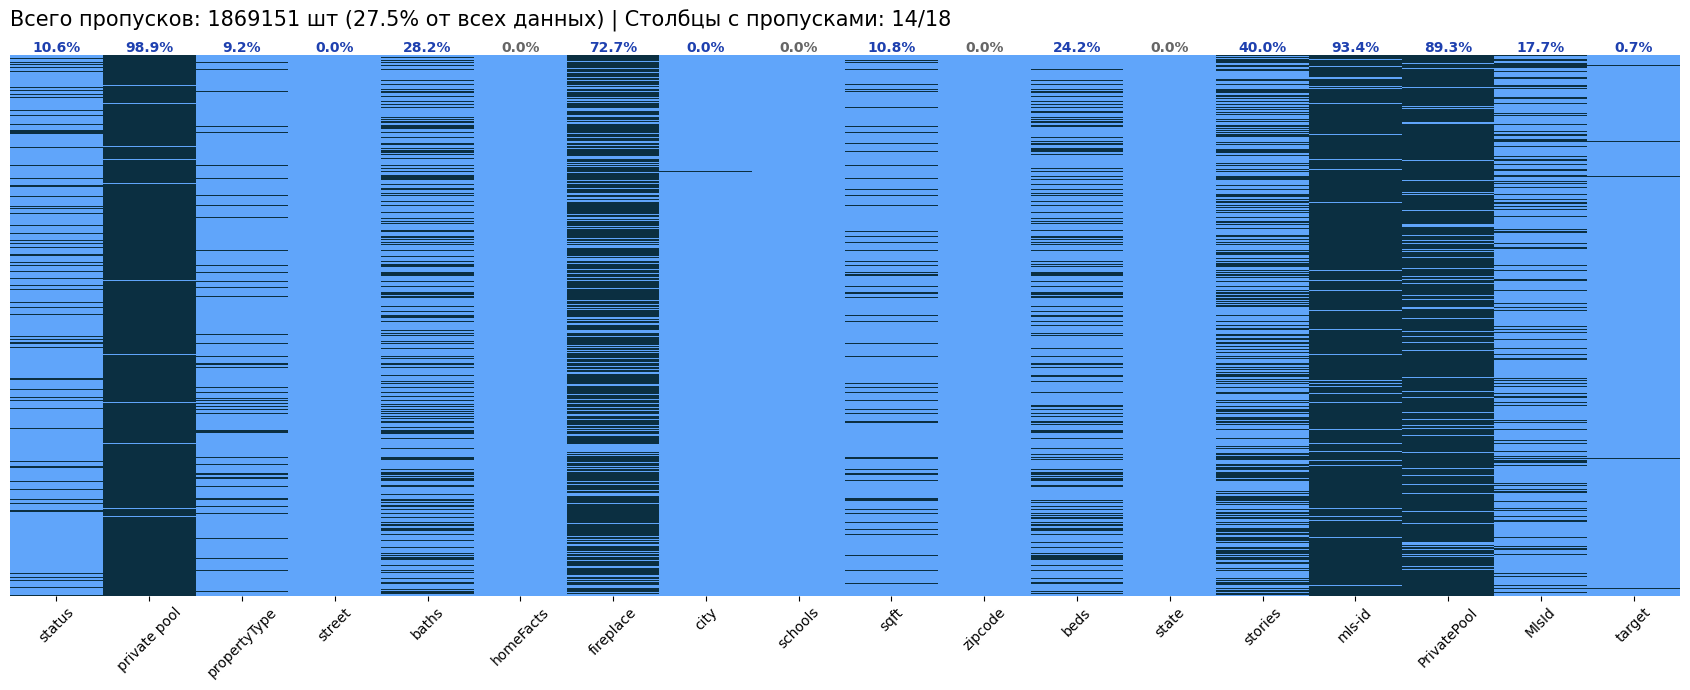

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   status        337267 non-null  object
 1   private pool  4181 non-null    object
 2   propertyType  342452 non-null  object
 3   street        377183 non-null  object
 4   baths         270847 non-null  object
 5   homeFacts     377185 non-null  object
 6   fireplace     103115 non-null  object
 7   city          377151 non-null  object
 8   schools       377185 non-null  object
 9   sqft          336608 non-null  object
 10  zipcode       377185 non-null  object
 11  beds          285903 non-null  object
 12  state         377185 non-null  object
 13  stories       226470 non-null  object
 14  mls-id        24942 non-null   object
 15  PrivatePool   40311 non-null   object
 16  MlsId         310305 non-null  object
 17  target        374704 non-null  object
dtypes: object(18)
memory usa

In [14]:
graph_null(df)
df.info()

<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 20px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
          <ul style="margin: 0; padding-left: 20px; color: black;">
            <li>Датасет состоит из <strong>377 185 строк и 18 (в том числе таргет)</strong>;</li>
            <li>Необходима предобработка признаков и приведения их к нужным типам;</li>
            <li>В данных очень много пропусков, предстоит большая работа по их заполненности;</li>
            <li>Всего пропусков <strong>1 869 151 шт (27.5 %)</strong> всех данных;</li>
            <li>Количество столбцов с пропусками <strong>14 из 18</strong>;</li>
            <li>Признаки: <strong>private, fireplace, mls-id, PrivatePool</strong> имеют более 70 % пустых значений, а где-то даже и более 90%.<br>Что-то удалим, а над чем-то посмотрим и подумаем, может чего можно будет полезного извлечь.</li>
          </ul>
        </div>
      </td>
      <td style="width: 40%; vertical-align: middle; border: none; text-align: right;">
        <img src="image/cl.jpg" alt="Рис" style="width: 100%; max-width: 400px;">
      </td>
    </tr>
  </table>
</div>

<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="font-weight: bold; color: #000000; margin-bottom: 10px;">
    Предварительно разобьём признаки на категории:
  </div>
  <table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
    <thead>
      <tr style="background: #1e40af; color: white;">
        <th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Местоположение</th>
        <th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Свойства недвижимости</th>
        <th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Иная информация</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">street</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">private pool/PrivatePool</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">status</td>
      </tr>
      <tr style="background: #f8fafc;">
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">city</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baths</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">propertyType</td>
      </tr>
      <tr>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">state</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">fireplace</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">homeFacts</td>
      </tr>
      <tr style="background: #f8fafc;">
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">zipcode</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">sqft</td>
        <td style="padding: 10px; border: 1px solid #d1d5db;"></td>
      </tr>
      <tr>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">mls-id/MlsId</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">beds</td>
        <td style="padding: 10px; border: 1px solid #d1d5db;"></td>
      </tr>
      <tr>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">schools</td>
        <td style="padding: 10px; border: 1px solid #d1d5db; color: black;">stories</td>
        <td style="padding: 10px; border: 1px solid #d1d5db;"></td>
      </tr>
    </tbody>
  </table>
    Начнём наш анализ с обратного порядка наших выделенных категорий: вначале посмотрим <strong>иную информацию</strong>, далее — <strong>свойства недвижимости</strong>, а после разберёмся с <strong>местоположением</strong>.
  </ul>
</div>


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">status</strong>
</div>

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   status        337267 non-null  object
 1   private pool  4181 non-null    object
 2   propertyType  342452 non-null  object
 3   street        377183 non-null  object
 4   baths         270847 non-null  object
 5   homeFacts     377185 non-null  object
 6   fireplace     103115 non-null  object
 7   city          377151 non-null  object
 8   schools       377185 non-null  object
 9   sqft          336608 non-null  object
 10  zipcode       377185 non-null  object
 11  beds          285903 non-null  object
 12  state         377185 non-null  object
 13  stories       226470 non-null  object
 14  mls-id        24942 non-null   object
 15  PrivatePool   40311 non-null   object
 16  MlsId         310305 non-null  object
 17  target        374704 non-null  object
dtypes: object(18)
memory usa

In [16]:
analize_feature('status')

Количество уникальных показателей: 159 шт
Количество пустых значений: 39918 шт, (10.6%)
Топ встречаемых показателей:
   1. for sale
   2. Active
   3. For sale
   4. foreclosure
   5. New construction
   6. Pending
   7. Pre-foreclosure
   8. Pre-foreclosure / auction
   9. P
  10. Under Contract Show
  11.  / auction
  12. Under Contract   Showing
  13. Active Under Contract
  14. New
  15. Under Contract
  16. Contingent
  17. Price Change
  18. Auction
  19. Foreclosed
  20. A Active


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">


<div style="font-weight: bold; color: #1e40af; margin-bottom: 10px;">Показателей для данного признака большое количество. Выполнен анализ признаков и создана следующая группировка статусов недвижимости для функции по преобразованию признака</div>
<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Активные продажи</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Активные продажи с условиями</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Новостройки</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Скоро в продаже</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">for sale</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active Under Contract</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">New construction</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Coming soon</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">For Sale</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active With Offer</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">New</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active with Contract</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">A Active</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active/Contingent</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active - Contingent</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active Contingent</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active With Contingencies</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active Contingency</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active Option</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active Option Contract</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Active Backup</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Ожидание подтверждения</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Контракты с условиями</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Подписание документов</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">С бекап-оферами</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Pending</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Contingent</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Under Contract</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Backup</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">P </td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Contingency</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Contract</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Back up</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Pending Offer</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Conditional</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Under contract</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Bckp</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Accepted Offer</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Проданные</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Исторические продажи</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Аукционы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Возвраты</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Sold</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">recently sold</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Auction</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Back on Market</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Closed</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Pre-foreclosure</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Re Activated</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Foreclosure</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Reactivated</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Foreclosed</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Аренда</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Изменение цены</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">for rent</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Price Change</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condo for rent</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Listing Extended</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Apartment for rent</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Lease/Purchase</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

In [17]:
group_status = {
    'Active': [
        'for sale', 'For Sale', 'Active', 'A Active'
    ],
    'Active with conditions': [
        'Active Under Contract', 'Active With Offer', 'Active with Contract',
        'Active/Contingent', 'Active - Contingent', 'Active Contingent',
        'Active With Contingencies', 'Active Contingency', 'Active Option',
        'Active Option Contract', 'Active Backup'
    ],
    'New': [
        'New construction', 'New'
    ],
    'Coming soon': [
        'Coming soon:'
    ],
    'Waiting for confirmantion': [
        'Pending', 'P ', 'Pending Offer', 'Accepted Offer'
    ],
    'Conditions': [
        'Contingent', 'Contingency', 'Conditional'
    ],
    'Signing': [
        'Under Contract', 'Contract', 'Under contract'
    ],
    'Backup': [
        'Backup', 'Back up', 'Bckp'
    ],
    'Sold': [
        'Sold:', 'Closed'
    ],
    'History sold': [
        'recently sold'
    ],
    'Auctions': [
        'Auction', 'Pre-foreclosure', 'Foreclosure', 'Foreclosed'
    ],
    'Back': [
        'Back on Market', 'Re Activated', 'Reactivated'
    ],
    'Rent': [
        'for rent', 'Condo for rent', 'Apartment for rent', 'Lease/Purchase'
    ],
    'Price Change': [
        'Price Change', 'Listing Extended'
    ]
}

In [18]:
df['group_status'] = df['status'].apply(
    lambda x: categorize_value(x, group_status)
)

In [19]:
analize_feature('group_status')

Количество уникальных показателей: 14 шт
Количество пустых значений: 39918 шт, (10.6%)
Топ встречаемых показателей:
   1. Active
   2. Auctions
   3. New
   4. Waiting for confirmantion
   5. Signing
   6. Other
   7. Conditions
   8. Price Change
   9. Sold
  10. Rent
  11. History sold
  12. Back
  13. Coming soon
  14. Backup


In [20]:
df['group_status'].value_counts()

Active                       306126
Auctions                      11920
New                            6165
Waiting for confirmantion      5385
Signing                        3033
Other                          1621
Conditions                     1018
Price Change                    591
Sold                            479
Rent                            413
History sold                    287
Back                            115
Coming soon                     110
Backup                            4
Name: group_status, dtype: int64

In [21]:
drop_list.extend(['status'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">propertyType</strong>
</div>

In [22]:
analize_feature('propertyType')

Количество уникальных показателей: 1280 шт
Количество пустых значений: 34733 шт, (9.2%)
Топ встречаемых показателей:
   1. single-family home
   2. Single Family
   3. Single Family Home
   4. condo
   5. lot/land
   6. Condo
   7. townhouse
   8. Land
   9. multi-family
  10. Condo/Townhome/Row Home/Co-Op
  11. Townhouse
  12. Traditional
  13. coop
  14. Multi Family
  15. High Rise
  16. Ranch
  17. mobile/manufactured
  18. Detached, One Story
  19. Single Detached, Traditional
  20. Contemporary


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">

<div style="font-weight: bold; color: #1e40af; margin-bottom: 10px;"> Аналогично предыдущему признаку выполнен анализ колонки и создана следующая группировка типов недвижимости для функции по преобразованию признака</div>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Отдельные дома</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Кондоминиумы/Апартаменты</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Таунхаусы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Многоквартирные дома</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">single-family home</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">condo</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">townhouse</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">multi-family</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Single Family</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condo</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Townhouse</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Multi Family</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Single Family Home</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condominium</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condo/Townhome/Row Home/Co-Op</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Multi-Family Home</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">SingleFamilyResidence</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condominium (Single Level)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condo/Townhome</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Duplex</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Single Detached</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condominium (2 Levels)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Row Home</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Triplex</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Detached</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Condominium (3+ Levels)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Townhome Style</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Fourplex</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Detached, One Story</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Apartment</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Townhouse-End Unit</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Multiplex</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Detached, Two Story</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Penthouse</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Townhouse-Interior</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">2-4 Units</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">One Story</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Studio</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">5-9 Units</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Two Story</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Loft</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">10+ Units</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">1 Story</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">One Level Unit</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Multiple Occupancy</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">2 Stories</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Flat</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">3+ Stories</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">High Rise</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Hi-Rise</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Mid-Rise</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Low-Rise</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Мобильные/модульные дома</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Земельные участки</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Кооперативы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Стиль Ранчо</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">mobile/manufactured</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">lot/land</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">coop</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Ranch</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Mobile / Manufactured</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Land</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Cooperative</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Rancher</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Mfd/Mobile Home</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Farms/Ranches</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Co-op</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Ranch, Traditional</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Manufactured Home</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Lot/Land</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Ranch, One Story</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Mobile Home</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Residential (<1 Acre)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Single Wide</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Residential (1+ Acre)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Double Wide</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Farm/Ranch House</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Manufactured Single-Wide</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Farm</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Manufactured Double-Wide</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Single Wide MH</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Современный/Модерн</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Традиционный</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Колониальный</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Ремесленный</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Contemporary</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Traditional</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Colonial</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Craftsman</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Contemporary/Modern</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Traditional, Transitional</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Colonial, Traditional</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Craftsman, Traditional</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Modern</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Modernist</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Contemporary/Modern, Traditional</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Urban Contemporary</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Бунгало</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Викторианский</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Средиземноморский/Испанский</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Кейп-Код</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Bungalow</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Victorian</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Mediterranean</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Cape Cod</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Bungalow, Traditional</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Victorian/Federal</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Spanish</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Cape</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Spanish/Mediterranean</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Florida</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Key West</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #1e40af; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Другие архитектурные стили</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">Federal, Tudor, Transitional, Mid-Century Modern, Prairie, Rustic Contemporary, Coastal Modern, A-Frame, Farmhouse, Cabin, Log Home, Custom, Other Style</td>
</tr>
</tbody>
</table>
</div>

In [23]:
group_property = {
    'Single-Family': [
        'single-family home', 'Single Family', 'Single Family Home', 'SingleFamilyResidence',
        'Single Detached', 'Detached', 'Detached, One Story', 'Detached, Two Story',
        'One Story', 'Two Story', '1 Story', '2 Stories', '3+ Stories'
    ],

    'Condominium/Apartment': [
        'condo', 'Condo', 'Condominium', 'Condominium (Single Level)', 'Condominium (2 Levels)',
        'Condominium (3+ Levels)', 'Apartment', 'apartment', 'Penthouse', 'Studio', 'Loft',
        'One Level Unit', 'Flat', 'High Rise', 'Hi-Rise', 'Mid-Rise', 'Low-Rise'
    ],

    'Townhouse': [
        'townhouse', 'Townhouse', 'Condo/Townhome/Row Home/Co-Op', 'Condo/Townhome',
        'Row Home', 'Townhome Style', 'Townhouse-End Unit', 'Townhouse-Interior'
    ],

    'Multi-Family': [
        'multi-family', 'Multi Family', 'Multi-Family Home', 'Duplex', 'Triplex', 'Fourplex',
        'Multiplex', '2-4 Units', '5-9 Units', '10+ Units', 'Multiple Occupancy'
    ],

    'Mobile/Manufactured': [
        'mobile/manufactured', 'Mobile / Manufactured', 'Mfd/Mobile Home', 'Manufactured Home',
        'Mobile Home', 'Single Wide', 'Double Wide', 'Manufactured Single-Wide',
        'Manufactured Double-Wide', 'Single Wide MH'
    ],

    'Land/Lot': [
        'lot/land', 'Land', 'Lot/Land', 'Residential (<1 Acre)',
        'Residential (1+ Acre)'
    ],

    'Co-op': [
        'coop', 'Cooperative', 'Co-op'
    ],

    'Ranch': [
        'Ranch', 'Rancher','Farms/Ranches', 'Ranch, Traditional', 'Ranch, One Story', 'Farm/Ranch House', 'Farm'
    ],

    'Contemporary/Modern': [
        'Contemporary', 'Contemporary/Modern', 'Modern', 'Modernist',
        'Contemporary/Modern, Traditional', 'Urban Contemporary'
    ],

    'Traditional': [
        'Traditional', 'Traditional, Transitional'
    ],

    'Colonial': [
        'Colonial', 'Colonial, Traditional'
    ],

    'Craftsman': [
        'Craftsman', 'Craftsman, Traditional'
    ],

    'Bungalow': [
        'Bungalow', 'Bungalow, Traditional'
    ],

    'Victorian': [
        'Victorian', 'Victorian/Federal'
    ],

    'Mediterranean/Spanish': [
        'Mediterranean', 'Spanish', 'Spanish/Mediterranean', 'Florida', 'Key West'
    ],

    'Cape Cod': [
        'Cape Cod', 'Cape'
    ],

    'Various Styles': [
        'Federal', 'Tudor', 'Transitional', 'Mid-Century Modern', 'Prairie',
        'Rustic Contemporary', 'Coastal Modern', 'A-Frame', 'Farmhouse',
        'Cabin', 'Log Home', 'Custom', 'Other Style'
    ]
}

In [24]:
df['group_property'] = df['propertyType'].apply(
    lambda x: categorize_value(x, group_property)
)

In [25]:
analize_feature('group_property')

Количество уникальных показателей: 18 шт
Количество пустых значений: 34857 шт, (9.2%)
Топ встречаемых показателей:
   1. Single-Family
   2. Condominium/Apartment
   3. Land/Lot
   4. Townhouse
   5. Multi-Family
   6. Traditional
   7. Co-op
   8. Mobile/Manufactured
   9. Contemporary/Modern
  10. Ranch
  11. Other
  12. Colonial
  13. Mediterranean/Spanish
  14. Various Styles
  15. Bungalow
  16. Cape Cod
  17. Craftsman
  18. Victorian


In [26]:
df['group_property'].value_counts()

Single-Family            197471
Condominium/Apartment     54685
Land/Lot                  31612
Townhouse                 18582
Multi-Family              12656
Traditional                6437
Co-op                      3841
Mobile/Manufactured        3530
Contemporary/Modern        3413
Ranch                      2741
Other                      2358
Colonial                   1281
Mediterranean/Spanish      1233
Various Styles             1228
Bungalow                    536
Cape Cod                    317
Craftsman                   296
Victorian                   111
Name: group_property, dtype: int64

In [27]:
drop_list.extend(['propertyType'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">homeFacts</strong>
</div>

In [28]:
analize_feature('homeFacts')

Количество уникальных показателей: 321009 шт
Количество пустых значений: 0 шт, (0.0%)
Топ встречаемых показателей:
   1. {'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '—', 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}
   2. {'atAGlanceFacts': [{'factValue': None, 'factLabel': 'Year built'}, {'factValue': None, 'factLabel': 'Remodeled year'}, {'factValue': None, 'factLabel': 'Heating'}, {'factValue': None, 'factLabel': 'Cooling'}, {'factValue': None, 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}
   3. {'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'fa

<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="font-weight: bold; color: #000000; margin-bottom: 10px;">Картина, конечно, так себе: по сути, в этом признаке запихан JSON, который необходимо привести во вменяемый вид (из строк в словари) и «распаковать» эти словари по новым колонкам в датасете.<br>Примеры строк из датасета</div>

  <table style="width: 100%; border: none; border-collapse: collapse;">
    <tr>
      <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
        <div style="font-size: 16px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
          <strong>Строка №8:</strong>
          <pre style="color: black;">
{'atAGlanceFacts': [
  {'factValue': '1970', 'factLabel': 'Year built'},
  {'factValue': '', 'factLabel': 'Remodeled year'},
  {'factValue': 'Forced Air', 'factLabel': 'Heating'},
  {'factValue': 'Central', 'factLabel': 'Cooling'},
  {'factValue': '', 'factLabel': 'Parking'},
  {'factValue': '124582', 'factLabel': 'lotsize'},
  {'factValue': '$68', 'factLabel': 'Price/sqft'}
]}
          </pre >
          <strong>Чаще всего встречаемая строка:</strong>
          <pre style="color: black;">
{'atAGlanceFacts': [
  {'factValue': '', 'factLabel': 'Year built'},
  {'factValue': '', 'factLabel': 'Remodeled year'},
  {'factValue': '', 'factLabel': 'Heating'},
  {'factValue': '', 'factLabel': 'Cooling'},
  {'factValue': '', 'factLabel': 'Parking'},
  {'factValue': '—', 'factLabel': 'lotsize'},
  {'factValue': None, 'factLabel': 'Price/sqft'}
]}
          </pre>
        </div>
      </td>
      <td style="width: 80%; vertical-align: middle; border: none; text-align: right;">
        <img src="image/homefacts.jpg" alt="Карта штатов США" style="width: 100%; max-width: 600px;">
      </td>
    </tr>
  </table>

  <ul style="margin: 0; padding-left: 20px; color: black; margin-top: 15px;">
    <li>Соответственно, из этого признака необходимо по <strong>factLabel</strong> создать новые признаки: <strong>'Year built', 'Remodeled year', 'Heating', 'Cooling', 'Parking', 'lotsize', 'Price/sqft'</strong>.<br>Значениями, соответственно, будут <strong>factValue</strong>.</li>
    <li>Конечно, чаще всего встречается пустота, но посмотрим после разбиения, как это на деле у нас будет.</li>
  </ul>
</div>


In [29]:
def group_fact(df, home_facts_column='homeFacts'):
    """
    Функция для преобразования колонки homeFacts из строкового формата в отдельные признаки

    Аргументы::
        df (DataFrame): исходный DataFrame с колонкой homeFacts
        home_facts_column (str): название колонки с данными homeFacts (по умолчанию 'homeFacts')

    Вывод:
        DataFrame: исходный DataFrame с добавленными колонками на основе factLabel из homeFacts
    """

    def parse_single_row(facts_str):
        """Обрабатывает одну строку с homeFacts"""
        if pd.isna(facts_str) or facts_str == '':
            return {}

        try:
            facts_dict = json.loads(facts_str)
        except:
            try:
                facts_dict = ast.literal_eval(facts_str)
            except:
                return {}

        result = {}
        if 'atAGlanceFacts' in facts_dict:
            for fact in facts_dict['atAGlanceFacts']:
                if ('factLabel' in fact and
                    'factValue' in fact and
                    fact['factValue'] not in [None, '', '—']):

                    # Создаем имя для колонки в регистре
                    safe_name = fact['factLabel'].replace('/', '_per_').replace(' ', '_').lower()
                    result[safe_name] = fact['factValue']

        return result

    # Применяем функцию и создаем новые колонки
    parsed_data = df[home_facts_column].apply(parse_single_row)

    # Создаем DataFrame из полученных словарей
    new_columns_df = pd.json_normalize(parsed_data)
    # Объединяем с исходным DataFrame
    df = pd.concat([df, new_columns_df], axis=1)

    return df

In [30]:
df = group_fact(df, 'homeFacts')

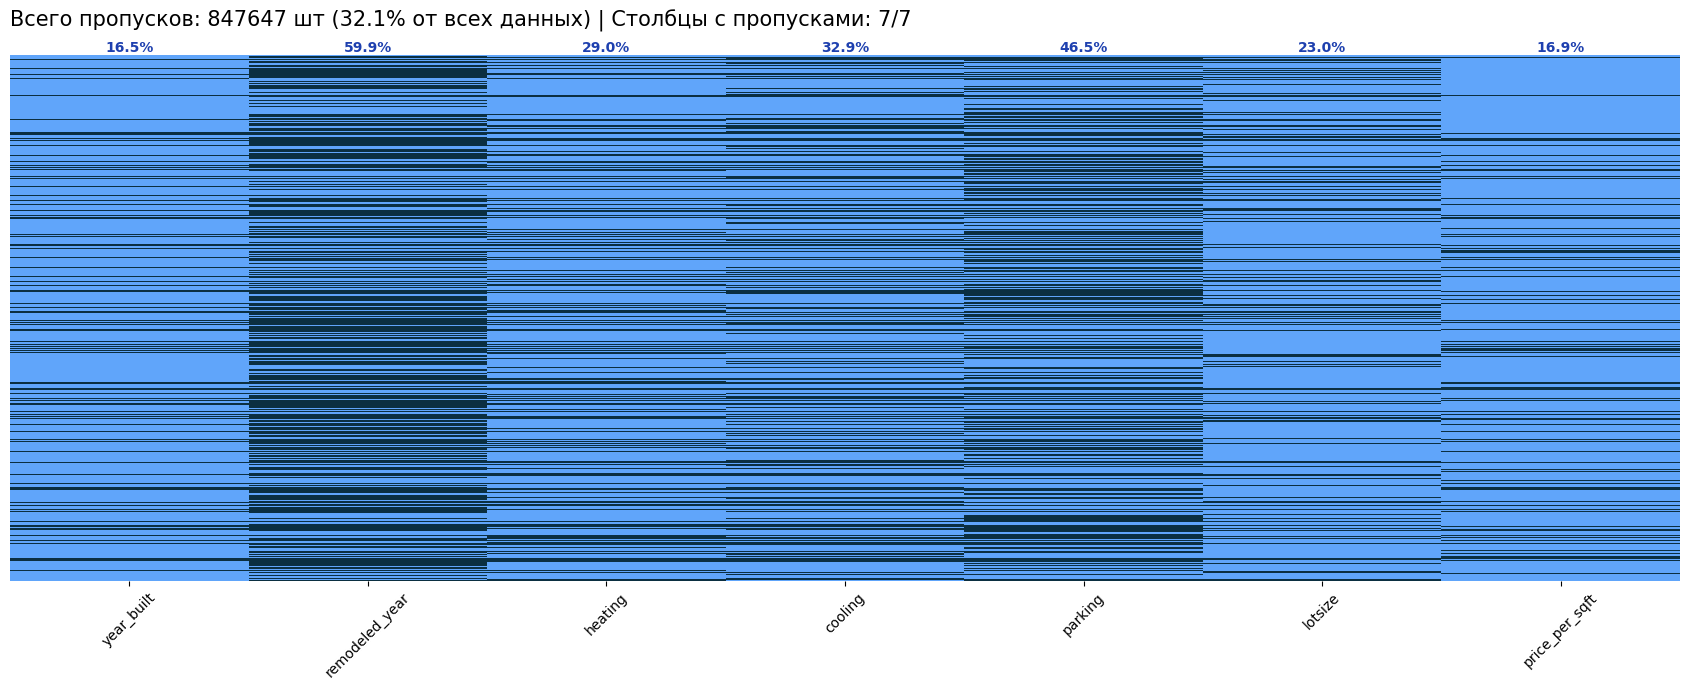

In [31]:
# проверим наши признаки на пропуски, что вышло
fact = df[['year_built', 'remodeled_year', 'heating', 'cooling', 'parking', 'lotsize', 'price_per_sqft']]
graph_null(fact)

<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Честно говоря картина получилась не такая уж и плачевная, и данные плюс минус заполнены, можно даже поработать с ними.
<br>
Взглянем на графике как это все дело обстоит
</div>

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">year_built</strong>
</div>

In [32]:
analize_feature('year_built')

Количество уникальных показателей: 229 шт
Количество пустых значений: 62374 шт, (16.5%)
Топ встречаемых показателей:
   1. 2019
   2. 2006
   3. 2005
   4. 2007
   5. 2018
   6. 2004
   7. 2017
   8. 2016
   9. 2008
  10. 2003
  11. 1950
  12. 1920
  13. 2002
  14. 2001
  15. 1925
  16. 2015
  17. 1955
  18. 1960
  19. 2000
  20. 1974


<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
        Тут у нас идут даты, по хорошему можно было бы его в datetime перевести, но, переведем в числовой! Почему?
Потому что при сравнении числового типа данных с датами у нас:
- Проще идет в обработке при обучении, т.е. меньше памяти ест, соответственно быстрее вычисления
- Большинство моделей ML лучше работают с числовыми, а некоторые вообще не переваривают даты
- Легче будет создавать производные признаки
      </div>
    </td>
    <td style="width: 20%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/year.jpg" alt="Карта штатов США" style="width: 100%; max-width: 300px;">
    </td>
  </tr>
</table>

</div>
</div>

<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="font-weight: bold; color: #000000; margin-bottom: 10px;">

Тут у нас идут даты, по хорошему можно было бы его в datetime перевести, но, переведем в числовой! Почему?
Потому что при сравнении числового типа данных с датами у нас:
- Проще идет в обработке при обучении, т.е. меньше памяти ест, соответственно быстрее вычисления
- Большинство моделей ML лучше работают с числовыми, а некоторые вообще не переваривают даты
- Легче будет создавать производные признаки
</div>

In [33]:
df['year_built'] = pd.to_numeric(df['year_built'], errors='coerce')

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">remodeled_year</strong>
</div>

In [34]:
analize_feature('remodeled_year')

Количество уникальных показателей: 153 шт
Количество пустых значений: 226110 шт, (59.9%)
Топ встречаемых показателей:
   1. 2006
   2. 2005
   3. 2007
   4. 2008
   5. 2004
   6. 1980
   7. 1970
   8. 2000
   9. 2003
  10. 1985
  11. 2002
  12. 1975
  13. 1990
  14. 1965
  15. 1983
  16. 2001
  17. 1995
  18. 1988
  19. 1962
  20. 1978


<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="font-weight: bold; color: #000000; margin-bottom: 10px;">
Ситуация аналогичная с <strong>year_built</strong>.
<br>
Добавим ещё дополнительный признак - разница между постройкой и ремонтом
</div>

In [35]:
# Преобразование формата
df['remodeled_year'] = pd.to_numeric(df['remodeled_year'], errors='coerce')
# Создание нового признака
df['difference_built'] = df['remodeled_year'] - df['year_built']
df['difference_built'].describe()

count    149646.000000
mean          6.295791
std          73.080243
min       -2020.000000
25%           0.000000
50%           0.000000
75%           9.000000
max        1110.000000
Name: difference_built, dtype: float64

<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="font-weight: bold; color: #000000; margin-bottom: 10px;">

Что по факту видим, что некоторые значения ушли в минуса, не совсем весело выходит.
<br>
Таким образом, исходя из того, что значение <strong>remodeled_year</strong> имеет больше пропусков, то мы его немного форматнем.
<br>
На его месте создадим булевый признак, который показывает был ли ремонт в доме или нет.
</div>

In [36]:
df['remodeled_year'] = df['remodeled_year'].notna()

In [37]:
drop_list.extend(['difference_built'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">heating</strong>
</div>

In [38]:
analize_feature('heating')

Количество уникальных показателей: 1983 шт
Количество пустых значений: 109332 шт, (29.0%)
Топ встречаемых показателей:
   1. Forced Air
   2. Forced air
   3. Other
   4. Electric
   5. Gas
   6. No Data
   7. Central Air
   8. Central Electric
   9. Central
  10. Heat Pump
  11. Central, Electric
  12. Baseboard
  13. Wall
  14. Electric Heat
  15. Heat pump
  16. Heating System
  17. Forced air, Heat pump
  18. Radiant
  19. Central Air, Ceiling Fan(s)
  20. Natural Gas Heat


<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="font-weight: bold; color: #000000; margin-bottom: 10px;">

<div style="font-weight: bold; color: rgb(0, 0, 0); margin-bottom: 10px;">Для признака heating выполнен анализ вхождений и создана следующая группировка систем отопления для функции по преобразованию признака</div>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Принудительное воздушное</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Тепловые насосы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Электрические системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Газовые системы</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">gas</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forcedair</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heatpump</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">electric heat</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">natural gas</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">furnace</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">reverse cycle</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">gas heat</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">hot air</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump - heat</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central gas</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air heating</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard - electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">natural gas heat</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air, gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump - electric backup</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">electric baseboard</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">gas forced air</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air, natural gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">geothermal</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">gas hot air/furnace</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air - gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">electric heating</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">gas - natural</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air, electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">electric source</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air - electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forcedair, heatpump</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Центральные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Водяные/паровые</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Радиационные</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Пропановые</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">hot water</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">radiant</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">propane</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central heating</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">steam</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">radiant floor</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">lpg</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central air</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">boiler</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">in floor</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">propane gas</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central furnace</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">radiator</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">radiant heating</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">propane/butane</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central heat</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">hot water/steam</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">radiant heat</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air, propane</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central, electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">hot water - gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard, radiant</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central, propane</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central, gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">hot water - oil</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central, zoned</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">radiators</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">steam heating</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Масляные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Дровяные/печные</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Настенные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Плинтусные системы</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">oil</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wood</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall furnace</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">fuel oil</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">stove</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall heater</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard - hot water</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">oil/hot air</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">pellet</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall unit</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard/wall</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">oil/hot water</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">fireplace</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall/window unit</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard heaters</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air, oil</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wood stove</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard electric</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">baseboard, oil</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">stove - wood</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wood/coal</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall heater</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wood burning</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Другие системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Без отопления</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">solar, other, see remarks, other heating, miscellaneous, various, multiple, zoned, dual, combination</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">none, no heating, no data, unknown</td>
</tr>
</tbody>
</table>
</div>

In [39]:
group_heating = {
    'Forced Air Systems': [
        'forced air', 'forcedair', 'furnace', 'hot air', 'forced air heating',
        'forced air, gas', 'forced air, natural gas', 'forced air - gas',
        'forced air, electric', 'forced air - electric', 'forcedair, heatpump'
    ],

    'Heat Pump Systems': [
        'heat pump', 'heatpump', 'reverse cycle', 'heat pump - heat',
        'heat pump(s)', 'heat pump - electric backup', 'geothermal'
    ],

    'Electric Systems': [
        'electric', 'electric heat', 'central electric', 'baseboard',
        'baseboard - electric', 'electric baseboard', 'wall electric',
        'electric heating', 'electric source'
    ],

    'Gas Systems': [
        'gas', 'natural gas', 'gas heat', 'central gas', 'natural gas heat',
        'gas forced air', 'gas hot air/furnace', 'gas - natural'
    ],

    'Central Systems': [
        'central', 'central heating', 'central air', 'central furnace',
        'central heat', 'central, electric', 'central, gas', 'central, zoned'
    ],

    'Hot Water/Steam Systems': [
        'hot water', 'steam', 'boiler', 'radiator', 'hot water/steam',
        'hot water - gas', 'hot water - oil', 'radiators', 'steam heating'
    ],

    'Radiant Systems': [
        'radiant', 'radiant floor', 'in floor', 'radiant heating',
        'radiant heat', 'baseboard, radiant'
    ],

    'Propane Systems': [
        'propane', 'lpg', 'propane gas', 'propane/butane',
        'forced air, propane', 'central, propane'
    ],

    'Oil Systems': [
        'oil', 'fuel oil', 'oil/hot air', 'oil/hot water',
        'forced air, oil', 'baseboard, oil'
    ],

    'Wood/Pellet Systems': [
        'wood', 'stove', 'pellet', 'fireplace', 'wood stove',
        'stove - wood', 'wood/coal', 'wood burning'
    ],

    'Wall Systems': [
        'wall furnace', 'wall heater', 'wall unit', 'wall/window unit',
        'wall gas', 'wall electric', 'wall heater'
    ],

    'Baseboard Systems': [
        'baseboard', 'baseboard - hot water', 'baseboard/wall',
        'baseboard heaters', 'baseboard electric'
    ],

    'Other Systems': [
        'solar', 'other', 'see remarks', 'other heating', 'miscellaneous',
        'various', 'multiple', 'zoned', 'dual', 'combination'
    ],

    'No Heating': [
        'none', 'no heating', 'no data', 'unknown', ''
    ]
}

In [40]:
df['group_heating'] = df['heating'].apply(
    lambda x: categorize_value(x, group_heating)
)

<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="margin: 0; padding-left: 20px; color: #000000; margin-bottom: 10px;">

<strong>Замечание по вопросу обработки пропусков</strong>
<br>
В данном признаке и подобных случаях, которые будут встречаться по дальнейшему анализу и подготовки признаков к обучению, принято решение о том, что пропуск является своего рода информацией, обозначающей отсутсвие каких либо критериев в извлеченных признаках <strong>homeFacts</strong>
</div>

In [41]:
drop_list.extend(['heating'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">cooling</strong>
</div>

In [42]:
analize_feature('cooling')

Количество уникальных показателей: 1444 шт
Количество пустых значений: 123967 шт, (32.9%)
Топ встречаемых показателей:
   1. Central
   2. Central Air
   3. No Data
   4. Has Cooling
   5. None
   6. Central Electric
   7. Wall
   8. Central Gas
   9. Central Heating
  10. Cooling System
  11. Central A/C
  12. Other
  13. Central A/C (Electric), Central Heat (Gas)
  14. Central A/C (Electric), Central Heat (Electric)
  15. Refrigeration
  16. Central, Electric
  17. Electric
  18. Evaporative
  19. Central Air, Gas Hot Air/Furnace
  20. Refrigeration, Ceiling Fan(s)


<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="font-weight: bold; color: #000000; margin-bottom: 10px;">

<div style="font-weight: bold; color: rgb(0, 0, 0); margin-bottom: 10px;">Группируем cooling для функции по преобразованию признака</div>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Центральные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Тепловые насосы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Оконные/настенные блоки</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Испарительные системы</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">window unit(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">evaporative</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central air</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump - ac</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall unit(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">evaporative cooling</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central a/c</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump(cooling)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">window/wall unit(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">evaporative cooler</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central cooling</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">heat pump for a/c</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall/window unit(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">evaporative cooler (swamp)</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central air conditioning</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">reverse cycle</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">window unit</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">evap. cooler</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central ac</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">geothermal</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall unit</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">both refrig & evap</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">ductless hp-mini split</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">window ac</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">mini-split unit(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">wall ac units</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central, electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">window/wall unit</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central, gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">air conditioning unit(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central air, electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">room air conditioner</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central air, gas</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central a/c (electric)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">central a/c (gas)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Рефрижераторные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Потолочные вентиляторы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Мультизональные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Принудительные воздушные</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">refrigeration</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">ceiling fan(s)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">multi-zone</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">electric refrigerated</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">ceiling fan</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">multizone a/c</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air heating</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">refridge wall/window</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">ceiling fans</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">multi-zone a/c</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air, gas</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">fans - ceiling</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">zoned</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">forced air, natural gas</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">ceiling fan, central</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">zoned a/c</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">ceiling fans, central electric</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">multi-zone cooling</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">multizone cooling</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">zoned cooling</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Высокоэффективные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Солнечные системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Чердачные/домовые вентиляторы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Программируемые системы</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">high efficiency</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">solar</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">attic fan</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">programmable thmstat</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">energy star cooling system</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">solar, refrigeration</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">whole house fan</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">programmable thermostat cooling</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">seer 13 or greater</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">solar rough-in(cooling)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">attic fan, central air</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">humidity control</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">90%+ high efficiency</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">solar on grid(cooling)</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">whole house exhaust ventilation</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">energy star qualified equipment</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Другие системы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Без охлаждения</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">other, other cooling, other (see remarks), see remarks, various, multiple, dual, combination, miscellaneous</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">none, no cooling, no data, no a/c, no air conditioning, no cooling/vent, unknown</td>
</tr>
</tbody>
</table>
</div>

In [43]:
group_cooling = {
    'Central Systems': [
        'central', 'central air', 'central a/c', 'central cooling', 'central air conditioning',
        'central ac', 'central electric', 'central gas', 'central, electric', 'central, gas',
        'central air, electric', 'central air, gas', 'central a/c (electric)', 'central a/c (gas)'
    ],

    'Heat Pump Systems': [
        'heat pump', 'heat pump - ac', 'heat pump(cooling)', 'heat pump for a/c',
        'reverse cycle', 'geothermal', 'ductless hp-mini split', 'mini-split unit(s)'
    ],

    'Window/Wall Units': [
        'window unit(s)', 'wall unit(s)', 'window/wall unit(s)', 'wall/window unit(s)',
        'window unit', 'wall unit', 'window ac', 'wall ac units', 'window/wall unit',
        'air conditioning unit(s)', 'room air conditioner'
    ],

    'Evaporative Systems': [
        'evaporative', 'evaporative cooling', 'evaporative cooler', 'evaporative cooler (swamp)',
        'evap. cooler', 'both refrig & evap'
    ],

    'Refrigeration Systems': [
        'refrigeration', 'electric refrigerated', 'refridge wall/window'
    ],

    'Ceiling Fans': [
        'ceiling fan(s)', 'ceiling fan', 'ceiling fans', 'fans - ceiling',
        'ceiling fan, central', 'ceiling fans, central electric'
    ],

    'Multi-Zone Systems': [
        'multi-zone', 'multizone a/c', 'multi-zone a/c', 'zoned', 'zoned a/c',
        'multi-zone cooling', 'multizone cooling', 'zoned cooling'
    ],

    'Forced Air Systems': [
        'forced air', 'forced air heating', 'forced air, gas', 'forced air, natural gas'
    ],

    'Other Systems': [
        'other', 'other cooling', 'other (see remarks)', 'see remarks', 'various',
        'multiple', 'dual', 'combination', 'miscellaneous'
    ],

    'No Cooling': [
        'none', 'no cooling', 'no data', 'no a/c', 'no air conditioning',
        'no cooling/vent', 'unknown', ''
    ],

    'High Efficiency Systems': [
        'high efficiency', 'energy star cooling system', 'seer 13 or greater',
        '90%+ high efficiency', 'energy star qualified equipment'
    ],

    'Solar Systems': [
        'solar', 'solar, refrigeration', 'solar rough-in(cooling)', 'solar on grid(cooling)'
    ],

    'Attic/Whole House Fans': [
        'attic fan', 'whole house fan', 'attic fan, central air', 'whole house exhaust ventilation'
    ],

    'Programmable Systems': [
        'programmable thmstat', 'programmable thermostat cooling', 'humidity control'
    ]
}

In [44]:
df['group_cooling'] = df['cooling'].apply(
    lambda x: categorize_value(x, group_cooling)
)

In [45]:
analize_feature('group_cooling')

Количество уникальных показателей: 10 шт
Количество пустых значений: 123967 шт, (32.9%)
Топ встречаемых показателей:
   1. Central Systems
   2. No Cooling
   3. Refrigeration Systems
   4. Other Systems
   5. Heat Pump Systems
   6. Window/Wall Units
   7. Evaporative Systems
   8. Forced Air Systems
   9. Multi-Zone Systems
  10. Ceiling Fans


In [46]:
drop_list.extend(['cooling'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">parking</strong>
</div>

In [47]:
analize_feature('parking')

Количество уникальных показателей: 3345 шт
Количество пустых значений: 175420 шт, (46.5%)
Топ встречаемых показателей:
   1. Attached Garage
   2. 2 spaces
   3. 1 space
   4. No Data
   5. Detached Garage
   6. Carport
   7. 3 spaces
   8. Off Street
   9. Carport, Attached Garage
  10. 1
  11. 4 spaces
  12. 2
  13. None
  14. Off street
  15. Attached Garage, Detached Garage
  16. On Street
  17. 0
  18. Attached Garage, Carport
  19. Parking Desc
  20. 6 spaces


<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="font-weight: bold; color: #000000; margin-bottom: 10px;">

<div style="font-weight: bold; color: rgb(0, 0, 0); margin-bottom: 10px;">Группируем parking для функции по преобразованию признака</div>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Пристроенный гараж</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Отдельный гараж</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Навесы</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Подъездные пути</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">attached garage</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">detached garage</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">carport</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">driveway</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">garage-attached</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">garage-detached</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">carport - 1 car</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">driveway paved</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">attached</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">detached</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">carport - 2 car</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">concrete driveway</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">2 car garage, attached garage</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">2 car garage, detached garage</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">attached carport</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">asphalt driveway</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">1 car garage, attached garage</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">1 car garage, detached garage</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">detached carport</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">circular driveway</td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Внеуличная парковка</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Уличная парковка</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Назначенная/резервная</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Парковочные места</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">off street</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">on street</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">assigned</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">parking lot</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">off street parking</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">on street parking</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">assigned parking</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">assigned, parking lot</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">paved parking</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">public on-street parking</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">assigned/reserved</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">unassigned, parking lot</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">1 off street</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">assigned parking space - 1</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">2 off street</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">assigned parking space - 2</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Крытая парковка</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">RV/Лодочная парковка</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Одно место</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Два места</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">covered</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">rv parking</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">1 space</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">2 spaces</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">covered parking</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">boat</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">1</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">2</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">covered lot</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">rv gate</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">parking space - 1</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">parking space - 2</td>
</tr>
<tr style="background: #f8fafc;">
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;"></td>
</tr>
</tbody>
</table>

<br>

<table style="width: 100%; border-collapse: collapse; background: white; border-radius: 6px; overflow: hidden;">
<thead>
<tr style="background: #20a2f8ff; color: white;">
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Множественные места</th>
<th style="padding: 12px; border: 1px solid #d1d5db; text-align: left;">Без парковки</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">3 spaces, 4 spaces, 5 spaces, 6 spaces, 3, 4, 5, 6, multiple spaces</td>
<td style="padding: 10px; border: 1px solid #d1d5db; color: black;">none, no parking, no garage, no data</td>
</tr>
</tbody>
</table>
</div>

In [48]:
group_parking = {
    'Attached Garage': [
        'attached garage', 'garage-attached', 'attached', 'garage attached',
        'attached - front', 'attached - side', 'attached - rear',
        '2 car garage, attached garage', '1 car garage, attached garage',
        '3 car garage, attached garage'
    ],

    'Detached Garage': [
        'detached garage', 'garage-detached', 'detached', 'garage detached',
        '2 car garage, detached garage', '1 car garage, detached garage',
        '3 car garage, detached garage'
    ],

    'Carport': [
        'carport', 'carport - 1 car', 'carport - 2 car', 'double carport',
        'carport-attached', 'carport-detached', 'attached carport',
        'detached carport'
    ],

    'Driveway': [
        'driveway', 'driveway paved', 'concrete driveway', 'asphalt driveway',
        'paved driveway', 'circular driveway', 'double wide drive',
        'driveway - concrete', 'driveway - pavers'
    ],

    'Off Street': [
        'off street', 'off street parking', 'off-street parking',
        '1 off street', '2 off street', 'paved parking',
        'concrete driveway, off street', 'asphalt driveway, off street'
    ],

    'On Street': [
        'on street', 'on-street parking', 'on street parking',
        'public on-street parking', 'curb parking'
    ],

    'Parking Lot': [
        'parking lot', 'assigned, parking lot', 'unassigned, parking lot',
        'paved parking, parking lot', 'asphalt, parking lot'
    ],

    'Assigned Parking': [
        'assigned', 'assigned parking', 'assigned parking space - 1',
        'assigned parking space - 2', 'assigned/reserved',
        '1 space assigned', '2 assigned spaces'
    ],

    'Covered Parking': [
        'covered', 'covered parking', 'covered lot',
        'assigned, covered', 'covered, guest'
    ],

    'RV/Boat Parking': [
        'rv parking', 'boat', 'rv-boat', 'rv gate',
        'rv accessible', 'rv gate, rv parking'
    ],

    'Garage Door Opener': [
        'garage door opener', 'electric door opener', 'opener',
        'garage door opener, oversized', 'keypad entry'
    ],

    'No Parking': [
        'none', 'no parking', 'no garage', 'no data',
        'no a/c', 'unknown', ''
    ],

    'Multiple Spaces': [
        '1 space', '2 spaces', '3 spaces', '4 spaces', '5 spaces',
        '6 spaces', '1', '2', '3', '4', '5', '6',
        'multiple spaces', '2+ spaces'
    ],

    'Other Parking': [
        'other', 'other parking', 'parking', 'parking space',
        'parking pad', 'parking under building', 'underground',
        'guest parking', 'visitor parking'
    ]
}

In [49]:
df['group_parking'] = df['parking'].apply(
    lambda x: categorize_value(x, group_parking)
)

In [50]:
analize_feature('group_parking')

Количество уникальных показателей: 12 шт
Количество пустых значений: 175420 шт, (46.5%)
Топ встречаемых показателей:
   1. Attached Garage
   2. No Parking
   3. Detached Garage
   4. Carport
   5. Off Street
   6. Driveway
   7. On Street
   8. Garage Door Opener
   9. Assigned Parking
  10. RV/Boat Parking
  11. Parking Lot
  12. Covered Parking


In [51]:
drop_list.extend(['parking'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">lotsize</strong>
</div>

<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="margin: 0; padding-left: 20px; color: #000000; margin-bottom: 10px;">

Вероятнее всего это размер участка под строительство. Там возможно быть и несколько домов - это предположение.

In [52]:
analize_feature('lotsize')

Количество уникальных показателей: 37391 шт
Количество пустых значений: 86706 шт, (23.0%)
Топ встречаемых показателей:
   1. No Data
   2. -- sqft lot
   3. 0.26 acres
   4. 0.25 acres
   5. 0.28 acres
   6. 0.27 acres
   7. 0.29 acres
   8. 0.34 acres
   9. 6,098 sqft
  10. 0.3 acres
  11. 7,405 sqft
  12. 0.31 acres
  13. 6,534 sqft
  14. 0.32 acres
  15. 4,356 sqft
  16. 10,000 sqft
  17. 5,227 sqft
  18. 5,000 sqft
  19. 0.33 acres
  20. 0.35 acres


<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="margin: 0; padding-left: 20px; color: #000000; margin-bottom: 10px;">
Пропуска есть - это можно проработать, но единственное что, необходимо как-то привести это в единую систему измерений.
<br>
Напишем функцию, которая уберет все цифры и выведем нам исключительно варианты написания едениц измерения, чтобы там проще было это распознать и определиться
</div>

In [53]:
extract_letters(df, 'lotsize')

Уникальные текстовые значения из lotsize:
 1. '' - 130623 шт
 2. 'sqft' - 120898 шт
 3. 'acres' - 57812 шт
 4. 'Sq Ft' - 27695 шт
 5. 'sqft lot' - 15328 шт
 6. 'Acres' - 12486 шт
 7. 'acres lot' - 5522 шт
 8. 'No Data' - 5330 шт
 9. 'acre' - 777 шт
10. 'Acre' - 572 шт
11. 'acre lot' - 142 шт


<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
          <div style="font-size: 19px; line-height: 1.5; font-family: 'Segoe UI', sans-serif; font-weight: normal;">
            Вот теперь не так уж и страшно выглядит, у нас есть понимание какие внутри варианты обозначений.
            <br>
            Единственный момент — это значения, где не указана единица измерения.
            <br>
            Плюс ещё есть ситуация, где можно сильно ошибиться: анализ вручную данных колонки lotsize показал, что есть слишком маленькие значения. В связи с этим предлагается следующая логика:
            <br>
            - Там, где «,» в цифрах — будем убирать (так как это целое число); там, где «.» в цифрах — оставлять (так как это дробное число).
            <br>
            - Соответственно, приведение к единому средству измерения: если в колонке последовательно «acr» — то это акры, и их надо привести в sqft; если в колонке последовательно «sq» — то это sqft, оставляем всё как есть.
            <br>
            - Если у нас нет слов в ячейках, а находятся цифры, то: от 0 до 100 — будем считать акрами, которые нужно перевести в sqft; если больше 100 — то это sqft. Почему так? Жильё пусть будет хотя бы от 9,3 м². (Надо будет проверить со стоимостью потом такие строки.)
            <br>
            - Если «No Data», «Nan» или символы с минусом — то пишем «Nan».
            <br>
            <br>
            Логика, если кратко, такова:
            <br>
            <br>
            <li>"0.25 acres" → 10890.0 (0.25 × 43560)</li>
            <li>"6,098 sqft" → 6098.0</li>
            <li>"0.5" → 21780.0 (число ≤ 100)</li>
            <li>≤ 100: всегда акры</li>
            <li>С «.»: дробное число</li>
            <li>С «,»: целое число</li>
            <br>
            <br>
            Посмотрим, что выйдет из этого.
          </div>
        </td>
        <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
          <img src="image/lotsize.jpg" alt="Карта штатов США" style="width: 100%; max-width: 400px;">
        </td>
      </tr>
    </table>
  </div>
</div>


In [54]:
def convert_to_sqft(value):
    """
    Конвертирует значение в квадратные футы (sqft)
    """
    # Проверка на пустые значения, No Data, NaN и символы с минусом
    if pd.isna(value) or value == 'No Data' or value == '' or '-' in str(value):
        return np.nan

    # Приводим к строке и нижнему регистру
    value_str = str(value).lower().strip()

    # Убираем запятые в цифрах (для разделения тысяч)
    value_str = value_str.replace(',', '')

    # Разделяем числовую часть и единицы измерения
    # Ищем числовую часть (может содержать точку для десятичных дробей)
    numeric_part = ''
    unit_part = ''

    # Извлекаем числовую часть
    for i, char in enumerate(value_str):
        if char.isdigit() or char == '.':
            numeric_part += char
        else:
            unit_part = value_str[i:].strip()
            break

    # Если не нашли числовую часть, возвращаем NaN
    if not numeric_part:
        return np.nan

    # Преобразуем числовую часть в float
    try:
        number = float(numeric_part)
    except ValueError:
        return np.nan

    # Определяем единицы измерения и конвертируем
    if 'acr' in unit_part:  # acres, acre, Acres, Acre
        # 1 acre = 43560 sqft
        return number * 43560
    elif 'sq' in unit_part:  # sqft, Sq Ft, sqft lot
        return number
    elif not unit_part:  # Если нет единиц измерения (только цифры)
        if number <= 100:  # Считаем акрами
            return number * 43560
        else:  # Считаем sqft
            return number
    else:  # Неизвестные единицы измерения
        return np.nan

In [55]:
df['lotsize_sqft'] = df['lotsize'].apply(convert_to_sqft)

In [56]:
cheсk_sample(df, 'lotsize','lotsize_sqft')

 lotsize_sqft        lotsize
      14374.8 0.33 acres lot
      13503.6     0.31 Acres
      11325.6     0.26 acres
      12196.8     0.28 acres
      19371.0          19371
       8184.0 8,184 sqft lot
        871.0       871 sqft
      20908.8     0.48 acres
          NaN            NaN
          NaN            NaN
          NaN            NaN
       6911.0           6911
       8000.0     8,000 sqft
      10925.0          10925
       2178.0     2,178 sqft
          NaN            NaN
          NaN            NaN
          NaN            NaN
          NaN            NaN
      17424.0          17424


<div style="background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<div style="margin: 0; padding-left: 20px; color: #000000; margin-bottom: 10px;">
Вроде как похоже на правду,  можем двигать дальше

In [57]:
drop_list.extend(['lotsize'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">price_per_sqft</strong>
</div>

In [58]:
analize_feature('price_per_sqft')

Количество уникальных показателей: 6503 шт
Количество пустых значений: 63738 шт, (16.9%)
Топ встречаемых показателей:
   1. No Data
   2. $1/sqft
   3. No Info
   4. $125/sqft
   5. $115/sqft
   6. $132/sqft
   7. $119/sqft
   8. $120/sqft
   9. $128/sqft
  10. $122/sqft
  11. $121/sqft
  12. $130/sqft
  13. $127/sqft
  14. $117/sqft
  15. $139/sqft
  16. $123/sqft
  17. $124/sqft
  18. $135/sqft
  19. $116/sqft
  20. $118/sqft


In [59]:
extract_letters(df, 'price_per_sqft')

Уникальные текстовые значения из price_per_sqft:
 1. '' - 183512 шт
 2. 'sqft' - 141223 шт
 3. 'Sq Ft' - 50251 шт
 4. 'No Data' - 1241 шт
 5. 'No Info' - 954 шт
 6. 'Contact manager' - 4 шт


Это признак цены за квадратный фут (price per sqft). Нужно извлечь числовые значения и обработать специальные случаи.

In [ ]:
def convert_price_per_sqft(price_str):
    """
    Преобразует цену за кв.фут в числовой формат
    """
    if pd.isna(price_str) or price_str in ['No Data', 'No Info', '']:
        return np.nan

    price_str = str(price_str).strip().lower()

    # Удаляем запятые и пробелы вокруг /
    price_str = price_str.replace(',', '').replace(' / ', '/')

    # Обрабатываем формат "$125/sqft" или "$125 / Sq. Ft."
    if '/sqft' in price_str or '/sq. ft.' in price_str or '/sq' in price_str:
        match = re.search(r'\$?(\d+\.?\d*)', price_str)
        if match:
            return float(match.group(1))

    # Обрабатываем чистые числа
    elif price_str.replace('$', '').replace('.', '').isdigit():
        return float(price_str.replace('$', ''))

    # Обрабатываем специальные случаи
    elif price_str in ['$1/sqft', '$2/sqft', '$3/sqft', '$4/sqft', '$5/sqft', '$6/sqft', '$7/sqft', '$8/sqft', '$9/sqft', '$10/sqft']:
        match = re.search(r'\$?(\d+)', price_str)
        if match:
            return float(match.group(1))

    # Обрабатываем "$0/sqft" как 0
    elif price_str == '$0/sqft':
        return 0.0

    return np.nan

# Применяем преобразование
df['price_per_sqft_clean'] = df['price_per_sqft'].apply(convert_price_per_sqft)
df['price_per_sqft_clean']

0         144.0
1         159.0
2         965.0
3         371.0
4           NaN
          ...  
377180    311.0
377181    337.0
377182    458.0
377183      NaN
377184    140.0
Name: price_per_sqft_clean, Length: 377185, dtype: float64

In [61]:
cheсk_sample(df, 'price_per_sqft', 'price_per_sqft_clean')

 price_per_sqft_clean price_per_sqft
                315.0 $315 / Sq. Ft.
                231.0      $231/sqft
                136.0           $136
                119.0           $119
                605.0           $605
                 53.0            $53
                  NaN            NaN
                189.0      $189/sqft
                117.0           $117
                149.0           $149
                172.0      $172/sqft
                319.0           $319
                  NaN            NaN
                151.0      $151/sqft
                  NaN            NaN
                230.0      $230/sqft
                  NaN            NaN
                  NaN            NaN
                137.0      $137/sqft
                481.0 $481 / Sq. Ft.


In [62]:
drop_list.extend(['price_per_sqft', 'homeFacts'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">private pool/PrivatePool</strong>
</div>

In [63]:
analize_feature('private pool')
analize_feature('PrivatePool')

Количество уникальных показателей: 1 шт
Количество пустых значений: 373004 шт, (98.9%)
Топ встречаемых показателей:
   1. Yes


Количество уникальных показателей: 2 шт
Количество пустых значений: 336874 шт, (89.3%)
Топ встречаемых показателей:
   1. yes
   2. Yes


<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
        По сути это одинаковые признаки, с одинаковым названием, которые можно объеденить в 1. Проверим их на пересечении, и если не пересекаются, то делаем оди признак где будут значения булевое значение - TRUE и False
Взглянем на графике как это все дело обстоит
      </div>
    </td>
    <td style="width: 70%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/bath.jpg" alt="Карта штатов США" style="width: 100%; max-width: 400px;">
    </td>
  </tr>
</table>

</div>
</div>

In [64]:
filtered_df = df[df['private pool'].notna() & df['PrivatePool'].notna()]
print(filtered_df)

Empty DataFrame
Columns: [status, private pool, propertyType, street, baths, homeFacts, fireplace, city, schools, sqft, zipcode, beds, state, stories, mls-id, PrivatePool, MlsId, target, group_status, group_property, year_built, heating, price_per_sqft, lotsize, remodeled_year, cooling, parking, difference_built, group_heating, group_cooling, group_parking, lotsize_sqft, price_per_sqft_clean]
Index: []

[0 rows x 33 columns]


In [65]:
# Конвертируем в булевы значения
df['private pool'] = df['private pool'].apply(lambda x: True if x == 'Yes' else False)
df['PrivatePool'] = df['PrivatePool'].apply(lambda x: True if (x == 'Yes' or x == 'yes') else False)

# Объединяем фичи в новую фичу с булевыми значениями
df['pool_bool'] = df.apply(
    lambda row: True if row['private pool'] or row['PrivatePool'] else False,
    axis=1
)

In [66]:
analize_feature('pool_bool')

Количество уникальных показателей: 2 шт
Количество пустых значений: 0 шт, (0.0%)
Топ встречаемых показателей:
   1. False
   2. True


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Собственно говоря вот и все, осталось только закинуть в списочек на удаление колонки из которых мы вычерпали полезную информацию
</div>

In [67]:
drop_list.extend(['private pool', 'PrivatePool'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">baths</strong>
</div>

In [68]:
analize_feature('baths')

Количество уникальных показателей: 229 шт
Количество пустых значений: 106338 шт, (28.2%)
Топ встречаемых показателей:
   1. 2 Baths
   2. 3 Baths
   3. 2
   4. 2.0
   5. 4 Baths
   6. 3.0
   7. 3
   8. Bathrooms: 2
   9. 2.5
  10. Bathrooms: 3
  11. 1
  12. 1.0
  13. 5 Baths
  14. 4.0
  15. 2.5 Baths
  16. 0
  17. 4
  18. 3.5
  19. Bathrooms: 1
  20. 2 ba


In [69]:
df.baths.sort_values().unique()

array(['-- baths', '0', '0 / 0', '0.0', '0.00', '0.5 Baths', '0.75 Baths',
       '1', '1 / 1 / 1 / 1', '1 / 1-0 / 1-0 / 1-0', '1 ba', '1,000',
       '1,250', '1,500', '1,750', '1-0 / 1-0 / 1', '1-2 Baths', '1.0',
       '1.1 Baths', '1.25 Baths', '1.5', '1.5 Baths', '1.5 ba', '1.5+',
       '1.75 Baths', '1.75 ba', '1.8 Baths', '10', '10 Baths', '10 ba',
       '10.0', '10.5', '10.5 Baths', '10.5+', '11', '11 Baths', '11 ba',
       '11.0', '11.5 Baths', '11.5+', '116 / 116 / 116', '12', '12 Baths',
       '12 ba', '12.0', '12.5', '12.5+', '13', '13 Baths', '13 ba',
       '13.0', '14', '14 Baths', '14.0', '14.5+', '15', '15 Baths',
       '15.0', '16', '16 Baths', '16 ba', '16.0', '17', '17 Baths',
       '17.0', '18', '18 Baths', '18.0', '19 Baths', '2', '2 Baths',
       '2 ba', '2 baths', '2,000', '2,250', '2,500', '2,750',
       '2-1 / 2-1 / 1-1 / 1-1', '2.0', '2.1 Baths', '2.2 Baths',
       '2.25 Baths', '2.25 ba', '2.5', '2.5 Baths', '2.5 ba', '2.5+',
       '2.75 Baths', '2

In [70]:
df[df.baths == '116 / 116 / 116']

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,...,remodeled_year,cooling,parking,difference_built,group_heating,group_cooling,group_parking,lotsize_sqft,price_per_sqft_clean,pool_bool
63514,Active,False,Multi-Family Home,321 Larkin Springs Rd,116 / 116 / 116,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Madison,"[{'rating': ['1', 'NR', '3', '1', '2', '1', 'N...",99999,...,False,Cooling System:,ATCHF,NaN,No Heating,No Cooling,No Parking,166618.0,16.0,False


In [71]:
df[df.baths == '750']

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,...,remodeled_year,cooling,parking,difference_built,group_heating,group_cooling,group_parking,lotsize_sqft,price_per_sqft_clean,pool_bool
1109,Active,False,"Attached or 1/2 Duplex, Traditional",3624 Douglas Ave,750,"{'atAGlanceFacts': [{'factValue': '1993', 'fac...",1,Dallas,"[{'rating': ['5', '5', '2', '10'], 'data': {'D...","1,758",...,True,"Central A/C (Electric), Central Heat (Gas)",NaN,0.0,NaN,Central Systems,NaN,2200.0,284.0,False
2022,Active,False,NaN,920 I St NW #411,750,"{'atAGlanceFacts': [{'factValue': '2013', 'fac...",NaN,Washington,"[{'rating': ['8', '8', '3', '8'], 'data': {'Di...","1,367",...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1097.0,False
3594,Active,False,NaN,601 W 11th Ave #409,750,"{'atAGlanceFacts': [{'factValue': '1981', 'fac...",NaN,DENVER,"[{'rating': ['5', 'NR', '5', '2'], 'data': {'D...",873,...,False,Central Air,NaN,NaN,Forced Air Systems,Central Systems,NaN,NaN,400.0,False
7564,Active,False,NaN,1260 Xavier St,750,"{'atAGlanceFacts': [{'factValue': '1936', 'fac...",NaN,DENVER,"[{'rating': ['2', '2', '2'], 'data': {'Distanc...","1,864",...,True,NaN,NaN,0.0,Electric Systems,NaN,NaN,NaN,300.0,False
7693,Active,False,Condo/Townhome,3314 Douglas Ave Unit 202D,750,"{'atAGlanceFacts': [{'factValue': '1984', 'fac...",3,Dallas,"[{'rating': ['4', '3', '2', '10'], 'data': {'D...","1,336",...,False,"Central A/C (Gas), Central Heat (Gas)",NaN,NaN,NaN,Central Systems,NaN,NaN,213.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372603,Active,False,NaN,601 Pennsylvania Ave NW #212,750,"{'atAGlanceFacts': [{'factValue': '1991', 'fac...",NaN,Washington,"[{'rating': ['8', '8', '3', '5'], 'data': {'Di...",801,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,561.0,False
375634,Active,False,"Condo/Townhome, Contemporary/Modern",3225 Turtle Creek Blvd #1646,750,"{'atAGlanceFacts': [{'factValue': '1998', 'fac...",NaN,Dallas,"[{'rating': ['5', '5', '2', '10'], 'data': {'D...",832,...,True,"Central A/C (Electric), Central Heat (Electric)",NaN,0.0,NaN,Central Systems,NaN,NaN,264.0,False
376012,Active,False,"Condo/Townhome, Other (See Remarks)",2262 Alterbrook Ln,750,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Dallas,"[{'rating': ['4', '3', '2', '10'], 'data': {'D...","2,102",...,False,"Central A/C (Electric), Central Heat (Gas), Zoned",NaN,NaN,NaN,Central Systems,NaN,NaN,221.0,False
376147,Active,False,"Condo/Townhome, Hi-Rise",3225 Turtle Creek Blvd #528,750,"{'atAGlanceFacts': [{'factValue': '1998', 'fac...",NaN,Dallas,"[{'rating': ['5', '5', '2', '10'], 'data': {'D...",837,...,True,"Central A/C (Electric), Central Heat (Gas)",NaN,0.0,NaN,Central Systems,NaN,NaN,287.0,False


In [72]:
df[df.baths == 'Bathrooms: 241']

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,...,remodeled_year,cooling,parking,difference_built,group_heating,group_cooling,group_parking,lotsize_sqft,price_per_sqft_clean,pool_bool
11118,For sale,False,Single Family,1204 E Helena Ave,Bathrooms: 241,"{'atAGlanceFacts': [{'factValue': '2014', 'fac...",NaN,McAllen,"[{'rating': ['6/10', 'NA', '4/10'], 'data': {'...","Total interior livable area: 3,770 sqft",...,True,Central,2 spaces,1.0,Forced Air Systems,Central Systems,No Parking,16117.2,119.0,False


<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
        Разброс ванн и их значения некоторых колонок довольно странные.

Например:
- ['116 / 116 / 116'] - либо ошибка парсинга, либо размер ванной комнаты. Но думаю, если мы уберем это значение, то сильно не помешаем датасету
- ['750'] - исходя из остальных характеристик, скорее всего имеется ввиду 7,5 комнат, поэтому скорректируем этот результат
- ['Bathrooms: 241']- что-то нереальное, на 4 спальни столько ванных комнат,  логично значение 1, или 2, или 4,но навеное тоже уберем его
- Есть значения где ванных комнат больше 15, 20 и т.д.
      </div>
    </td>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/bb.jpg" alt="Карта штатов США" style="width: 100%; max-width: 400px;">
    </td>
  </tr>
</table>

</div>
</div>

In [73]:
def clean_baths_data(baths):
    if pd.isna(baths):
        return np.nan

    baths = str(baths).strip()

    # Сначала обработаем специальные случаи
    special_cases = {
        'no data': [
            'Bathrooms: SemiMod', 'Sq. Ft.', '~', '—', '-- baths', '116 / 116 / 116',
            'Bathrooms: 241'
        ],
        '0.0': ['0', '0 / 0', '0.0', '0.00'],
        '2.0': ['1-2'],
        '3.0': ['1-0 / 1-0 / 1'],
        '4.0': ['1 / 1 / 1 / 1', '1 / 1-0 / 1-0 / 1-0'],
        '5.0': ['3-1 / 2-2'],
        '6.0': ['2-1 / 2-1 / 1-1 / 1-1'],
        '7.5': ['750']
    }

    for group, patterns in special_cases.items():
        if baths in patterns:
            if group == 'no data':
                return np.nan
            else:
                return float(group)  # сразу возвращаем число

    # Обработка формата "Bathrooms: X"
    if baths.startswith('Bathrooms:'):
        num = baths.replace('Bathrooms:', '').strip()
        if num.isdigit():
            return float(num)

    # Регулярные выражения для извлечения чисел
    patterns = [
        r'^(\d{1,4}),(\d+)\+?$',      # "7,500+"
        r'^(\d+\.?\d*)\+?$',          # "1.5+", "2+"
        r'(\d+\.?\d*)\s*[Bb]aths?',   # "1.5 Baths", "2 baths"
        r'(\d+\.?\d*)\s*ba',          # "1.5 ba", "2 ba"
        r'^(\d+)$',                   # "1", "2"
    ]

    for pattern in patterns:
        match = re.search(pattern, baths)
        if match:
            if ',' in pattern:  # для формата "7,500+"
                num = match.group(1) + '.' + match.group(2)
            else:
                num = match.group(1)

            try:
                return float(num)  # сразу возвращаем число
            except ValueError:
                continue

    return np.nan


In [74]:
# Применение
df['baths_clean'] = df['baths'].apply(clean_baths_data)

In [75]:
df['baths_clean'].unique()

array([ 3.5 ,  3.  ,  2.  ,  8.  ,   nan,  1.75,  4.  ,  5.  ,  1.  ,
        7.  ,  2.1 ,  2.5 ,  4.5 ,  6.  ,  5.5 ,  1.5 ,  0.  ,  1.25,
        9.  ,  2.25, 12.  ,  2.75,  7.5 , 10.  , 19.  , 18.  , 11.  ,
        1.1 ,  6.5 , 16.  , 13.  , 14.  ,  8.5 , 17.  , 10.5 , 20.  ,
       40.  , 24.  , 22.  ,  3.1 ,  3.25, 32.  , 27.  , 26.  ,  9.5 ,
       15.  , 35.  ,  3.75, 29.  , 21.  ,  5.2 , 14.5 , 76.  , 23.  ,
        3.3 , 43.  , 34.  ,  2.2 , 55.  , 25.  , 12.5 , 44.  ,  0.5 ,
        4.25,  4.75,  0.75,  4.1 ,  5.25, 41.  ,  1.8 , 36.  , 30.  ,
       28.  ,  2.8 , 64.  , 11.5 , 39.  , 42.  ,  3.2 , 60.  ,  6.75,
       68.  ])

In [76]:
df[df.baths_clean >= 15]

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,...,cooling,parking,difference_built,group_heating,group_cooling,group_parking,lotsize_sqft,price_per_sqft_clean,pool_bool,baths_clean
1349,For sale,False,Multi Family,1501 1503 1513 S Walnut St # 106,Bathrooms: 19,"{'atAGlanceFacts': [{'factValue': '1920', 'fac...",NaN,Bloomington,"[{'rating': ['7/10', '6/10'], 'data': {'Distan...","Total interior livable area: 10,900 sqft",...,Central,19 spaces,NaN,Gas Systems,Central Systems,No Parking,261360.0,138.0,False,19.0
2532,for sale,False,multi-family,164 E 7th St #T,18 Baths,"{'atAGlanceFacts': [{'factValue': '1900', 'fac...",NaN,New York,"[{'rating': ['6/10', '5/10', '6/10', 'None/10'...","12,324 sqft",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1217.0,False,18.0
3354,Active,False,Multi-Family Home,1684 Murchison St,18,"{'atAGlanceFacts': [{'factValue': '1965', 'fac...",NaN,Los Angeles,"[{'rating': ['1', '5', 'NR', '7', 'NR', '9', '...",12052,...,Wall Unit(s),0,NaN,Wall Systems,Window/Wall Units,No Parking,14871.0,299.0,False,18.0
6031,for sale,False,single-family home,3206 Briscoe Trl,19 Baths,"{'atAGlanceFacts': [{'factValue': '2007', 'fac...",yes,San Antonio,"[{'rating': ['7/10', '7/10'], 'data': {'Distan...","3,090 sqft",...,Central,Attached Garage,NaN,Forced Air Systems,Central Systems,Attached Garage,7057.0,119.0,True,19.0
6285,for sale,False,multi-family,2509 NW 9th Ave,16 Baths,"{'atAGlanceFacts': [{'factValue': '1968', 'fac...",NaN,Wilton Manors,"[{'rating': ['7/10', '5/10', '4/10'], 'data': ...","13,925 sqft",...,Central,16,NaN,Forced Air Systems,Central Systems,No Parking,18295.2,190.0,False,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370350,For sale,False,Multi Family,1402 N Durant St,16.0,"{'atAGlanceFacts': [{'factValue': '1984', 'fac...",NaN,Santa Ana,"[{'rating': ['2/10', '1/10', '3/10'], 'data': ...","11,200 sqft",...,Wall,No Data,NaN,Gas Systems,No Cooling,No Parking,NaN,303.0,False,16.0
372938,for sale,False,multi-family,532 E 5th St #1,20 Baths,"{'atAGlanceFacts': [{'factValue': '2012', 'fac...",NaN,New York,"[{'rating': ['6/10', '5/10', '6/10', 'None/10'...","11,500 sqft",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,957.0,False,20.0
373744,for sale,False,multi-family,1233 N New Hampshire Ave,16 Baths,"{'atAGlanceFacts': [{'factValue': '1958', 'fac...",NaN,Los Angeles,"[{'rating': ['2/10', '7/10', '4/10'], 'data': ...","10,012 sqft",...,NaN,14,NaN,NaN,NaN,No Parking,9931.0,399.0,False,16.0
375371,for sale,False,multi-family,1540 260th St,16 Baths,"{'atAGlanceFacts': [{'factValue': '1989', 'fac...",NaN,Harbor City,"[{'rating': ['6/10', '6/10', '4/10'], 'data': ...","11,557 sqft",...,Central,12,NaN,Forced Air Systems,Central Systems,No Parking,10554.0,277.0,False,16.0


---------------

In [77]:
cheсk_sample(df, 'baths','baths_clean')

 baths_clean        baths
         NaN          NaN
         3.0      3 Baths
         0.0            0
         NaN          NaN
         4.0      4 Baths
         3.0      3 Baths
         3.5          3.5
         NaN          NaN
         4.0         4 ba
         NaN          NaN
         3.0      3 Baths
         NaN          NaN
         1.0 Bathrooms: 1
         3.0      3 Baths
         3.0      3 Baths
         2.0            2
         3.0      3 Baths
         2.0      2 Baths
         1.0            1
         3.0            3


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Ну вроде для большого значения ванных комнат и спален тоже много, поэтому результаты оставим вменяемыми.
<!-- При начальном анализе у нас было в колонке 28.2% пропусков - значение не маленькое. Предлагается создать бинарную колонку, которая будет отмечать изначально пропущенные значения, чтобы помочь модели уловить паттерн пропуска изначального. -->

In [78]:
drop_list.extend(['baths'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">fireplace</strong>
</div>

In [79]:
analize_feature('fireplace')

Количество уникальных показателей: 1653 шт
Количество пустых значений: 274070 шт, (72.7%)
Топ встречаемых показателей:
   1. yes
   2. Yes
   3. 1
   4. 2
   5. Not Applicable
   6. Fireplace
   7. 3
   8. Living Room
   9. LOCATION
  10. Wood Burning
  11. Gas/Gas Logs
  12. No
  13. Fireplace YN
  14. Special Features
  15. 1 Fireplace
  16. 0
  17. FAMILYRM
  18. Fireplace Features
  19. Great Room
  20. Wood


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Ну что тут сказать, очень много пропусков очень много вариаций каминов и средств отопления.
Возьмем за правило там где пропущено - FALSE, там где явно указано что его нет - FALSE, а там где есть TRUE

In [80]:
def categorize_fireplace_robust(value):
    """
    Функция для определения наличия камина
    """
    if pd.isna(value) or value == '' or value == ' ':
        return False

    value_str = str(value).strip().lower()

    # Категоричные случаи отсутствия камина
    no_fireplace_cases = [
        'no', '0', 'not applicable', 'n/k', 'none', 'no fireplace',
        'fireplace yn', 'see agent', 'n/a', 'na', 'false', 'number',
        'fireplace features', 'special features', 'unit features',
        'bath features', 'bedroom features', 'location', 'extras',
        'misc #2', 'fireplace type', 'other (see remarks)',
        'presently inoperative'
    ]

    if value_str in no_fireplace_cases:
        return False

    # Числовые значения больше 0 - есть камин
    if value_str.isdigit():
        return int(value_str) > 0

    # Ключевые слова, указывающие на наличие камина
    fireplace_indicators = [
        # Основные типы каминов
        'fireplace', 'fire', 'frplc', 'fp', 'burning', 'hearth',
        'mantle', 'chimney', 'flue', 'stove', 'insert',

        # Типы топлива
        'gas', 'wood', 'electric', 'pellet', 'propane', 'ventless',
        'vented', 'log', 'logs', 'lpg', 'natural gas',

        # Расположение (комнаты где обычно есть камины)
        'living room', 'family room', 'great room', 'familyrm', 'fam rm',
        'den', 'master bedroom', 'bedroom', 'dining room', 'kitchen',
        'basement', 'rec room', 'bonus room', 'hearth room',

        # Конструктивные особенности
        'brick', 'stone', 'masonry', 'factory built', 'pre-fab',
        'free standing', 'freestnd', 'wall mounted', 'direct vent',
        'see through', 'two way', 'two sided', 'multi sided',

        # Аксессуары и компоненты
        'gas starter', 'gas log', 'wood burning', 'gas burning',
        'electric logs', 'fire pit', 'firepit', 'woodstove',
        'wood-burning', 'wood stove', 'woodburning',

        # Количественные указатели
        'one', 'two', 'three', 'four', '1', '2', '3', '4', '5', '6', '7',
        '1 fireplace', '2 fireplace', '3 fireplace', '2 fireplaces',
        '3+', '4+', '2+'
    ]

    # Проверяем наличие хотя бы одного индикатора
    for indicator in fireplace_indicators:
        if indicator in value_str:
            return True

    # Специфичные случаи наличия
    if value_str in ['yes', 'one', 'two', 'three', '1', '2', '3']:
        return True

    return False


In [81]:
# Применяем улучшенную версию
df['fireplace_clear'] = df['fireplace'].apply(categorize_fireplace_robust)

# Анализ результатов
print("Статистика преобразования:")
print(f"Всего записей: {len(df)}")
print(f"С камином: {df['fireplace_clear'].sum()} ({df['fireplace_clear'].mean():.2%})")
print(f"Без камина: {(~df['fireplace_clear']).sum()} ({(~df['fireplace_clear']).mean():.2%})")

Статистика преобразования:
Всего записей: 377185
С камином: 97597 (25.88%)
Без камина: 279588 (74.12%)


In [82]:
cheсk_sample(df, 'fireplace', 'fireplace_clear')

 fireplace_clear fireplace
           False       NaN
            True       yes
            True       yes
           False       NaN
           False       NaN
           False       NaN
           False       NaN
           False       NaN
           False       NaN
           False       NaN
            True         1
           False       NaN
           False       NaN
           False       NaN
           False       NaN
            True       yes
            True       yes
           False       NaN
            True         1
           False       NaN


In [83]:
analize_feature('fireplace_clear')

Количество уникальных показателей: 2 шт
Количество пустых значений: 0 шт, (0.0%)
Топ встречаемых показателей:
   1. False
   2. True


In [84]:
drop_list.extend(['fireplace'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">sqft</strong>
</div>

In [85]:
analize_feature('sqft')

Количество уникальных показателей: 25405 шт
Количество пустых значений: 40577 шт, (10.8%)
Топ встречаемых показателей:
   1. 0
   2. 1,200 sqft
   3. 1,000 sqft
   4. 1,100 sqft
   5. 1,800 sqft
   6. 1,500 sqft
   7. --
   8. 2,000 sqft
   9. 1,400 sqft
  10. 1,600 sqft
  11. 800 sqft
  12. 1,300 sqft
  13. 900 sqft
  14. 1,440 sqft
  15. 2,400 sqft
  16. 960 sqft
  17. 2,200 sqft
  18. 1,200
  19. 3,000 sqft
  20. 2,100 sqft


In [86]:
extract_letters(df, 'sqft')

Уникальные текстовые значения из sqft:
 1. '' - 194448 шт
 2. 'sqft' - 159059 шт
 3. 'Total interior livable area  sqft' - 23678 шт


In [87]:
def extract_numbers_from_sqft(value):
    """
    Извлекает только числовую часть из значения в колонке sqft
    """
    if pd.isna(value):
        return None

    # Преобразуем в строку
    str_value = str(value)

    # Ищем все числа (включая с запятыми)
    numbers = re.findall(r'[\d,]+', str_value)

    if numbers:
        # Берем первое найденное число и убираем запятые
        number_str = numbers[0].replace(',', '')
        try:
            return int(number_str)
        except ValueError:
            return None
    else:
        return None

# Применяем функцию к колонке
df['area'] = df['sqft'].apply(extract_numbers_from_sqft)

# Проверяем результат
print("Уникальные числовые значения:")
print(df['area'].value_counts().head(20))


Уникальные числовые значения:
0.0       11854
1200.0     1426
1000.0     1027
1500.0     1014
1800.0      988
1100.0      938
1400.0      918
2000.0      872
1600.0      835
800.0       755
1300.0      738
1440.0      736
960.0       712
900.0       702
2400.0      681
2200.0      610
1344.0      605
1152.0      601
1700.0      597
2100.0      586
Name: area, dtype: int64


In [88]:
drop_list.extend(['sqft'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">beds</strong>
</div>

In [89]:
analize_feature('beds')

Количество уникальных показателей: 1184 шт
Количество пустых значений: 91282 шт, (24.2%)
Топ встречаемых показателей:
   1. 3 Beds
   2. 4 Beds
   3. 3
   4. 2 Beds
   5. 4
   6. 2
   7. Baths
   8. 3 bd
   9. 5 Beds
  10. 4 bd
  11. 3.0
  12. 5
  13. 2 bd
  14. 4.0
  15. 1
  16. 6 Beds
  17. 5 bd
  18. 2.0
  19. 6
  20. 5.0


In [90]:
def clean_beds_data(beds):
    """
    Универсальная функция для очистки данных о количестве спален
    Возвращает целое число или None для некорректных значений
    """
    # Обработка пропущенных значений
    if pd.isna(beds):
        return None

    beds_str = str(beds).strip()

    # Паттерны для пропуска (возвращаем None)
    skip_patterns = [
        r'.*acre', r'.*sqft', r'^Bath', r'.*--', r'^\s*$', r'Based on Redfin.*',
        r'^\d+\.\d+\s+acres?', r'^\d+\.\d+\s+sqft', r'^\d+,\d+\s+sqft',
        r'^\d+\.\d+$'
    ]

    for pattern in skip_patterns:
        if re.match(pattern, beds_str, re.IGNORECASE):
            return None

    # Паттерны для извлечения чисел из форматов спален
    bed_patterns = [
        r'^(\d+)\s*Beds?$',
        r'^(\d+)\s*bd$',
        r'^(\d+)$',
        r'^(\d+)\.0$',
        r'^(\d+)\.\d+$',
        r'^(\d+)\s+Beds?',
        r'^(\d+)\s+bd'
    ]

    for pattern in bed_patterns:
        match = re.match(pattern, beds_str, re.IGNORECASE)
        if match:
            number = int(match.group(1))
            # Ограничиваем разумным диапазоном (0-20 спален)
            if 0 <= number <= 20:
                return number

    # Дополнительные специфичные случаи
    specific_cases = {
        '0': 0,
        '0.0': 0,
        '1.0': 1,
        '2.0': 2,
        '3.0': 3,
        '4.0': 4,
        '5.0': 5,
        '6.0': 6,
        '7.0': 7,
        '8.0': 8,
        '9.0': 9,
        '10.0': 10,
        '12.0': 12,
        '14.0': 14,
        '16.0': 16,
        'Baths': None,
        'Bath': None,
        ' ': None,
        '-- bd': None,
        '-- sqft': None
    }

    if beds_str in specific_cases:
        return specific_cases[beds_str]

    # Последняя попытка - извлечь любое число из строки
    match = re.search(r'(\d+)', beds_str)
    if match:
        number = int(match.group(1))
        if 0 <= number <= 20:
            return number

    # Если ничего не подошло
    return None

# Применение функции
df['beds_cleaned'] = df['beds'].apply(clean_beds_data)

# Проверка результатов
print("Статистика после очистки:")
print(f"Всего записей: {len(df)}")
print(f"Выполнена коррекция позиций: {df['beds_cleaned'].notna().sum()}")
print(f"Пропуски: {df['beds_cleaned'].isna().sum()}")

print("\nРаспределение значений:")
print(df['beds_cleaned'].value_counts().sort_index())

Статистика после очистки:
Всего записей: 377185
Выполнена коррекция позиций: 246950
Пропуски: 130235

Распределение значений:
0.0      1230
1.0      5698
2.0     47716
3.0     97744
4.0     63713
5.0     20328
6.0      6272
7.0      1758
8.0      1178
9.0       478
10.0      263
11.0      131
12.0      184
13.0       47
14.0       42
15.0       31
16.0       68
17.0       12
18.0       31
19.0        6
20.0       20
Name: beds_cleaned, dtype: int64


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Пропусков у нас прибавилось, было <strong>89803 шт (24.6%)</strong>, стало <strong>127657 шт (35.0%)</strong> - это связано с тем, что были просто забиты ячейки текстовыми значениями не имеющую информацию, например <strong>`-- bd`</strong>
<br>
</div>

In [91]:
cheсk_sample(df, 'beds', 'beds_cleaned')

 beds_cleaned   beds
          4.0      4
          3.0 3 Beds
          5.0      5
          NaN    NaN
          1.0      1
          NaN    NaN
          NaN    NaN
          6.0 6 Beds
          NaN    NaN
          NaN    NaN
          2.0 2 Beds
          NaN    1.0
          4.0 4 Beds
          5.0 5 Beds
          3.0 3 Beds
          NaN    NaN
          4.0 4 Beds
          2.0 2 Beds
          NaN    NaN
          NaN    NaN


In [92]:
drop_list.extend(['beds'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">stories</strong>
</div>

In [93]:
analize_feature('stories')

Количество уникальных показателей: 348 шт
Количество пустых значений: 150715 шт, (40.0%)
Топ встречаемых показателей:
   1. 1.0
   2. 2.0
   3. 1
   4. 2
   5. 3.0
   6. 0.0
   7. One
   8. 0
   9. 3
  10. 9.0
  11. 2.00
  12. Two
  13. 4.0
  14. 2 Story
  15. 1 Story
  16. 1.00
  17. 4
  18. 3+
  19. 6.0
  20. 1.50


In [94]:
df.stories.unique()

array([nan, '2.0', '1.0', '3.0', 'One', '2', 'Multi/Split', '4.0', '0.0',
       '0', 'One Level', '1', '9.0', '3', '1 Level, Site Built',
       'One Story', '3.00', '1.00', '14.0', 'Two', '3+', '1 Story', '5.0',
       '2 Story', 'Ranch/1 Story', 'Condominium', 'Stories/Levels', '7.0',
       '2 Level, Site Built', '2 Level', '15', '3 Level, Site Built', '4',
       '22.0', '2.00', '6.0', '1.0000', 'Lot', '3 Story', 'Three Or More',
       '1.5', '1 Level', 'Two Story or More', 'Site Built, Tri-Level',
       '54.0', '23', 'Farm House', '8.0', '16.0', '1.50', '18', '9', '21',
       '8', '12.0', 'Split Level w/ Sub', '11.0', '18.0', '1.5 Stories',
       '7', '11', 'Townhouse', '12', '21.0', '16', '1.5 Story/Basement',
       '28.0', 'Traditional', '2.5 Story', '17', '2.0000', '63.0',
       'Acreage', 'Ground Level, One', '6', 'Split Foyer', '2 Stories',
       '27.0', '19.0', '2.50', '1.30', '2 Story/Basement', 'Split Level',
       '1.5 Story', '1.5 Level', '2 Or More Stories',
  

In [95]:
def clean_stories_data(stories):
    """
    Очищает и стандартизирует данные о количестве этажей
    """
    if pd.isna(stories):
        return np.nan

    stories_str = str(stories).strip()

    # Пропускаем явно некорректные значения
    skip_patterns = [
        r'^\s*$', r'^None$', r'Stories/Levels', r'Dwelling Stories',
        r'Total Floors in Bldg', r'Bedroom - Split Plan',
        r'Based on Redfin', r'.*acres?', r'.*sqft'
    ]

    for pattern in skip_patterns:
        if re.match(pattern, stories_str, re.IGNORECASE):
            return np.nan

    # Числовые значения (самый простой случай)
    if re.match(r'^\d+\.?\d*$', stories_str):
        try:
            return float(stories_str)
        except ValueError:
            return np.nan

    # Специфичные числовые форматы
    numeric_patterns = [
        r'^(\d+\.?\d*)$',
        r'^(\d+)\.\d+$',
        r'^(\d+),\s*(\d+)$',
    ]

    for pattern in numeric_patterns:
        match = re.match(pattern, stories_str)
        if match:
            try:
                return float(match.group(1))
            except ValueError:
                continue

    # Текстовые описания этажей
    text_mappings = {
        # Один этаж
        'One': 1, 'One Level': 1, 'One Story': 1, '1 Story': 1,
        'Ranch/1 Story': 1, 'Ranch': 1, '1 Level': 1,
        '1 Story/Ranch': 1, '1 Story Basement': 1,
        'Ground Level, One': 1, '1 Story/F.R.O.G.': 1,
        'Bungalow': 1,

        # Полтора этажа
        '1.5': 1.5, '1.50': 1.5, '1.5000': 1.5, '1.500': 1.5,
        'One and One Half': 1.5, '1 1/2 Levels': 1.5,
        '1.5 Stories': 1.5, '1.5 Story/Basement': 1.5,
        '1.5 Story': 1.5, '1.5 Level': 1.5,
        '1 1/2 Story': 1.5,

        # Два этажа
        'Two': 2, '2 Story': 2, '2 Stories': 2, 'Two Story or More': 2,
        '2 Level': 2, '2 Levels': 2, '2 Or More Stories': 2,
        'Two Stories': 2, '2 Story or 2 Level': 2,

        # Три и более этажей
        'Three Or More': 3, '3+': 3, '3+ Story': 3,
        'Multi-Level': 3, 'Multi Level': 3, 'Multi-Story': 3,
        '3 Story': 3, '3 Stories': 3, '3 Level': 3, '3 Levels': 3,

        # Разные варианты
        'Multi/Split': 2, 'Split Level': 2, 'Split Foyer': 2,
        'Bi-Level': 2, 'Raised Ranch': 2, 'Split Entry (Bi-Level)': 2,
        'Tri-Level': 3, 'Tri Level': 3,

        # Кондоминиумы и таунхаусы
        'Condominium': 2, 'Townhouse': 2, 'High-Rise': 10,
        'Mid-Rise': 5, 'Condo': 2,

        # Мобильные дома
        'Manufactured Doublewide': 1, 'Mobile': 1,
        'Manufactured Singlewide': 1,
    }

    # Проверяем точные совпадения
    if stories_str in text_mappings:
        return text_mappings[stories_str]

    # Проверяем частичные совпадения
    for key, value in text_mappings.items():
        if key.lower() in stories_str.lower():
            return value

    # Извлекаем числа из сложных строк
    number_match = re.search(r'(\d+\.?\d*)', stories_str)
    if number_match:
        try:
            num = float(number_match.group(1))
            # Ограничиваем разумным диапазоном (0-10 этажей для жилых домов)
            if 0 <= num <= 10:
                return num
        except ValueError:
            pass

    return np.nan

In [96]:
# Очищаем данные
df['stories_cleaned'] = df['stories'].apply(clean_stories_data)
df['stories_cleaned'].describe()

count    225432.000000
mean          1.913553
std           4.246398
min           0.000000
25%           1.000000
50%           1.500000
75%           2.000000
max        1120.000000
Name: stories_cleaned, dtype: float64

In [97]:
drop_list.extend(['stories'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">street</strong>
</div>

In [98]:
analize_feature('street')

Количество уникальных показателей: 337076 шт
Количество пустых значений: 2 шт, (0.0%)
Топ встречаемых показателей:
   1. Address Not Disclosed
   2. Undisclosed Address
   3. (undisclosed Address)
   4. Address Not Available
   5. Unknown Address
   6. 2103 E State Hwy 21
   7. 11305 Gulf Fwy
   8. 17030 Youngblood Rd.
   9. NE 58th Cir
  10. 9470 Lancaster Rd. SW
  11. 1 Palmer Dr
  12. 8426 Terrace Valley Circle
  13. 9845 Basil Western Rd NW
  14. 6320 SW 89th Court Road
  15. 8447 SW 99th Street Rd
  16. 5221 S. Zapata Hwy
  17. Whitetail Trail
  18. Stone Bluff Drive
  19. 3435 Heather Garden Trail
  20. 2005 West Happy Valley Road


<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 20px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
Уникальных значений очень много, ну оно и логично, это адреса. Также мы видим в адресах мусорные значения которые выбиваются в топ по количеству встречаемости. Подготовим немного колонку для дальнейшего анализа и чистки - приведем в нижний регистр, уберем номера домов, чтобы сократить уникальность и мусорные значения заменим на np.nan. Вообще колонка слишком уникальна, возмонжо её полностью удалим в дальнейшем, но на данном этапе просто подготовим её.
      </div>
    </td>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/street.jpg" alt="" style="width: 100%; max-width: 300px;">
    </td>
  </tr>
</table>

</div>
</div>

In [99]:
def clean_and_categorize_address(address):
    """
    Очистка и категоризация адресов
    Возвращает np.nan для пустых и мусорных адресов,
    иначе адрес в нижнем регистре без номера дома в начале
    """
    if pd.isna(address) or address in ['', ' ']:
        return np.nan

    address_str = str(address).strip()

    # Категории для "мусорных" адресов
    undisclosed_keywords = [
        'undisclosed', 'not disclosed', 'not available', 'unknown',
        'coming soon', 'sold out', 'for gps purposes only', 'tba'
    ]

    address_lower = address_str.lower()
    for keyword in undisclosed_keywords:
        if keyword in address_lower:
            return np.nan

    # Проверяем на валидные адреса (содержат цифры и буквы)
    if any(char.isdigit() for char in address_str) and any(char.isalpha() for char in address_str):
        # Убираем номер дома в начале адреса
        cleaned_address = re.sub(r'^\d+\s*', '', address_str)
        cleaned_address = cleaned_address.strip()

        # Возвращаем очищенный адрес в нижнем регистре
        return cleaned_address.lower() if cleaned_address else np.nan
    else:
        return np.nan

In [100]:
df['street_cleaned'] = df['street'].apply(clean_and_categorize_address)

In [101]:
drop_list.extend(['street'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">сity</strong>
</div>

In [102]:
analize_feature('city')

Количество уникальных показателей: 2026 шт
Количество пустых значений: 34 шт, (0.0%)
Топ встречаемых показателей:
   1. Houston
   2. San Antonio
   3. Miami
   4. Jacksonville
   5. Dallas
   6. Brooklyn
   7. Chicago
   8. New York
   9. Charlotte
  10. Las Vegas
  11. Fort Worth
  12. Orlando
  13. Austin
  14. Fort Lauderdale
  15. Cleveland
  16. Nashville
  17. Tampa
  18. Philadelphia
  19. Washington
  20. Los Angeles


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
В целях сокращения возможных дубликатов из-за разного регистра и вариантов написания, а также возможных пропусков, сделаем небольшую предобработку.
</div>

In [103]:
def clean_city_name(city):
    """
    Очистка и стандартизация названий городов
    """
    if pd.isna(city) or str(city).strip() in ['', ' ', 'Other', 'Other City - In The State Of Florida']:
        return np.nan

    city_str = str(city).strip()

    # Приводим к стандартному регистру (каждое слово с заглавной)
    city_cleaned = city_str.title()

    # Стандартизируем common случаи
    city_cleaned = city_cleaned.replace('St ', 'St. ').replace('Ft ', 'Fort ')

    # Убираем лишние пробелы
    city_cleaned = ' '.join(city_cleaned.split())

    return city_cleaned

In [104]:
df['city_cleaned'] = df['city'].apply(clean_city_name)

In [105]:
drop_list.extend(['city'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">state</strong>
</div>

In [106]:
analize_feature('state')

Количество уникальных показателей: 39 шт
Количество пустых значений: 0 шт, (0.0%)
Топ встречаемых показателей:
   1. FL
   2. TX
   3. NY
   4. CA
   5. NC
   6. TN
   7. WA
   8. OH
   9. IL
  10. NV
  11. GA
  12. CO
  13. PA
  14. MI
  15. DC
  16. AZ
  17. IN
  18. OR
  19. MA
  20. UT


In [107]:
# Небольшая коррекция дублирующих признаков
df['state'] = df['state'].replace('Fl', 'FL')

<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
А остальное оставим всё как есть и едем дальше
</div>

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">zipcode</strong>
</div>

In [108]:
analize_feature('zipcode')

Количество уникальных показателей: 4549 шт
Количество пустых значений: 0 шт, (0.0%)
Топ встречаемых показателей:
   1. 32137
   2. 33131
   3. 34747
   4. 78245
   5. 34759
   6. 33132
   7. 33137
   8. 78253
   9. 78254
  10. 33130
  11. 34746
  12. 33160
  13. 32164
  14. 33133
  15. 33308
  16. 33178
  17. 33141
  18. 77845
  19. 33140
  20. 33304


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Ничего критичного не нашел, но предлагается на данном этапе выполнить парсинг по zipcode с сайта http://api.zippopotam.us/ и выдернуть информацию дополнительную информацию. Вот такой вид json можно вытащить:
</div>



```json
{
   "post code": "90210",
   "country": "United States",
   "country abbreviation": "US",
   "places": [
       {
           "place name": "Beverly Hills",
           "longitude": "-118.4065",
           "state": "California",
           "state abbreviation": "CA",
           "latitude": "34.0901"
       }
   ]
}
```


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Но у нас есть города и улицы, и аббревиатуры сайтов, поэтому достанем только два показателя: longitude и latitude
</div>



In [109]:
# Сначала получим ВСЕ уникальные ZIP-коды
unique_zips = df['zipcode'].unique()
print(f"Уникальных ZIP-кодов: {len(unique_zips)}")

# Словарь для кэширования результатов
zip_cache = {}

def get_zip_coords_cached(zip_code):
    if zip_code in zip_cache:
        return zip_cache[zip_code]

    try:
        response = requests.get(f"http://api.zippopotam.us/us/{zip_code}", timeout=5)
        if response.status_code == 200:
            data = response.json()
            lat = float(data['places'][0]['latitude'])
            lon = float(data['places'][0]['longitude'])
            zip_cache[zip_code] = (lat, lon)
            time.sleep(0.1)  # небольшая пауза чтобы не забанили
            return (lat, lon)
    except Exception as e:
        print(f"Ошибка для ZIP {zip_code}: {e}")

    zip_cache[zip_code] = (None, None)
    return (None, None)

# Получаем координаты только для уникальных кодов
zip_coords_map = {}
for zip_code in tqdm(unique_zips):
    zip_coords_map[zip_code] = get_zip_coords_cached(zip_code)


Уникальных ZIP-кодов: 4549


100%|██████████| 4549/4549 [26:12<00:00,  2.89it/s]


In [110]:
df['latitude'] = df['zipcode'].map(lambda x: zip_coords_map.get(x, (None, None))[0])
df['longitude'] = df['zipcode'].map(lambda x: zip_coords_map.get(x, (None, None))[1])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">mls-id/MlsId</strong>
</div>

In [111]:
analize_feature('mls-id')

Количество уникальных показателей: 24907 шт
Количество пустых значений: 352243 шт, (93.4%)
Топ встречаемых показателей:
   1. No MLS#
   2. No 
   3. 1498550
   4. 39888954
   5. 608063
   6. 19-3389
   7. 201906177
   8. 1020766
   9. 241766
  10. 20193733
  11. DW19268386
  12. 1530716
  13. 201909981
  14. 241962
  15. 19-3683
  16. 19010197
  17. 19-5523
  18. 20193103
  19. 19-5064
  20. 74184012


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Есть значения пустые, заменим их на Nan
</div>

In [112]:
# Заменяем проблемные значения на NaN
problematic_values = ['No MLS#', 'No ', ' ', '']
df['mls-id'] = df['mls-id'].replace(problematic_values, np.nan)
# Удаляем слишком короткие значения
df.loc[df['mls-id'].str.len() < 3, 'mls-id'] = np.nan

In [113]:
analize_feature('MlsId')

Количество уникальных показателей: 232944 шт
Количество пустых значений: 66880 шт, (17.7%)
Топ встречаемых показателей:
   1. NO MLS
   2. No MLS #
   3.  A, Houston, TX 77008
   4.  12A, Orlando, FL 32833
   5.  B, Houston, TX 77008
   6.  1, South Boston, MA 02127
   7. No 
   8.  B, Houston, TX 77007
   9. No mls
  10.  11A, Orlando, FL 32833
  11.  2, Washington, DC 20002
  12.  1, Washington, DC 20002
  13.  2, Washington, DC 20010
  14.  2, Washington, DC 20009
  15.  3A, Orlando, FL 32833
  16.  1A, Orlando, FL 32833
  17.  A, Austin, TX 78721
  18. 2088662
  19. 1412350
  20.  0, Doral, FL 33178


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
Тут ситуация по хуже, есть и адреса и пустые значения..
</div>

In [114]:
# Альтернатива: удаляем по паттернам
def is_valid_mls_id(mls_id):
    if pd.isna(mls_id):
        return False

    mls_str = str(mls_id).strip()

    # Слишком короткие
    if len(mls_str) < 3:
        return False

    # Содержит запятые (это адрес)
    if ',' in mls_str:
        return False

    # Начинается с пробела и буквы (паттерн адресов типа " A, Houston")
    if re.match(r'^\s+[A-Z],', mls_str):
        return False

    # Мусорные значения
    garbage_terms = ['no mls', 'nomls', 'none', 'na', 'n/a']
    if any(term in mls_str.lower() for term in garbage_terms):
        return False

    return True

# Применяем умную фильтрацию
df['MlsId'] = df['MlsId'].apply(lambda x: x if is_valid_mls_id(x) else np.nan)

In [115]:
df[['MlsId','mls-id']]

,MlsId,mls-id
0,611019,NaN
1,201916904,NaN
2,FR19221027,NaN
3,14191809,NaN
4,861745,NaN
...,...,...
377180,A10702700,NaN
377181,10374233,NaN
377182,NaN,NaN
377183,NaN,NaN


<div style="background: linear-gradient(135deg, #dbeafe 0%, #93c5fd 50%, #60a5fa 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
<ul style="margin: 0; padding-left: 20px; color: black;">
После предварительной чистки мы можем заметить что данные колонки можно объеденить в одну. Пустое значение в одной колонки заполняет значением из другой и наоборот
</div>

In [116]:
def create_unified_mls_id(row):
    """
    Создает единый MLS ID из двух колонок
    Основной признак: MlsId, резервный: mls-id
    """
    # Сначала проверяем MlsId (основной признак)
    if pd.notna(row['MlsId']) and is_valid_mls_id(row['MlsId']):
        return row['MlsId']

    # Затем проверяем mls-id (резервный признак)
    elif pd.notna(row['mls-id']) and is_valid_mls_id(row['mls-id']):
        return row['mls-id']

    else:
        return np.nan

# Применяем объединение
df['id_mls'] = df.apply(create_unified_mls_id, axis=1)

In [117]:
drop_list.extend(['MlsId','mls-id'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">schools</strong>
</div>

In [118]:
analize_feature('schools')

Количество уникальных показателей: 297365 шт
Количество пустых значений: 0 шт, (0.0%)
Топ встречаемых показателей:
   1. [{'rating': [], 'data': {'Distance': [], 'Grades': []}, 'name': []}]
   2. [{'rating': ['4/10', '5/10', '6/10'], 'data': {'Distance': ['39.69mi', '39.69mi', '39.69mi'], 'Grades': ['9-12', '6-8', 'PK-5']}, 'name': ['Fort Hancock High School', 'Fort Hancock Middle School', 'Benito Martinez Elementary School']}]
   3. [{'rating': ['4/10', '6/10', '3/10'], 'data': {'Distance': ['3.62mi', '3.62mi', '3.62mi'], 'Grades': ['6-8', 'PK-5', '9-12']}, 'name': ['Horizon Middle School', 'Desert Hills Elementary School', 'Horizon High School']}]
   4. [{'rating': ['5/10', '3/10', '5/10'], 'data': {'Distance': ['9.71mi', '8.92mi', '1.56mi'], 'Grades': ['5-8', '9-12', 'K-4']}, 'name': ['Cheatham Middle School', 'Cheatham Co Central', 'West Cheatham Elementary School']}]
   5. [{'rating': ['10/10', '2/10'], 'data': {'Distance': ['22.4 mi', '1.5 mi'], 'Grades': ['PK-8', '9-12']}, 'name

In [119]:
df.schools.value_counts().index.to_list()[1]

"[{'rating': ['4/10', '5/10', '6/10'], 'data': {'Distance': ['39.69mi', '39.69mi', '39.69mi'], 'Grades': ['9-12', '6-8', 'PK-5']}, 'name': ['Fort Hancock High School', 'Fort Hancock Middle School', 'Benito Martinez Elementary School']}]"

<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
    <tr>
      <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
        <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
          <pre style="color: black;">
Вот что из себя представляет признак школы:
{
'rating': список рейтингов школ,
    'data': {
        'Distance': список расстояний до школ,
        'Grades': список классов/уровней образования
    },
    'name': список названий школ
}

Для начала избавимся от признака schools и создадим признаки по каждому показатею
          </pre>
        </div>
      </td>
      <td style="width: 80%; vertical-align: middle; border: none; text-align: right;">
        <img src="image/school.jpg" alt="Карта штатов США" style="width: 100%; max-width: 300px;">
      </td>
    </tr>
  </table>
  </ul>
</div>


In [ ]:
def extract_schools_features(df, schools_column='schools'):
    """
    Извлекает признаки из колонки schools и создает новые колонки:
    - schools_rating: список рейтингов школ
    - schools_distance: список расстояний до школ
    - schools_grades: список классов школ
    - schools_name: список названий школ

    Parameters:
    df (DataFrame): исходный датафрейм
    schools_column (str): название колонки с данными о школах

    Returns:
    pd.DataFrame: датафрейм с новыми колонками
    """

    # Создаем временные списки для новых колонок
    ratings_list = []
    distances_list = []
    grades_list = []
    names_list = []

    # Обрабатываем каждую строку в колонке schools
    for schools_data in df[schools_column]:
        try:
            # Проверяем на пустые значения
            if pd.isna(schools_data) or schools_data == '' or schools_data == '[]' or schools_data == 'None':
                ratings_list.append(np.nan)
                distances_list.append(np.nan)
                grades_list.append(np.nan)
                names_list.append(np.nan)
                continue

            # Преобразуем строку в список словарей
            if isinstance(schools_data, str):
                schools_list = ast.literal_eval(schools_data)
            else:
                schools_list = schools_data

            # Извлекаем данные из первого элемента списка (если список не пустой)
            if schools_list and isinstance(schools_list, list) and len(schools_list) > 0:
                school_info = schools_list[0]

                # Проверяем, есть ли данные в словаре
                ratings = school_info.get('rating', [])
                distances = school_info.get('data', {}).get('Distance', [])
                grades = school_info.get('data', {}).get('Grades', [])
                names = school_info.get('name', [])

                # Если какие-то списки пустые, ставим np.nan
                ratings_list.append(ratings if ratings else np.nan)
                distances_list.append(distances if distances else np.nan)
                grades_list.append(grades if grades else np.nan)
                names_list.append(names if names else np.nan)
            else:
                # Если список пустой, добавляем np.nan
                ratings_list.append(np.nan)
                distances_list.append(np.nan)
                grades_list.append(np.nan)
                names_list.append(np.nan)

        except (ValueError, SyntaxError, AttributeError) as e:
            # В случае ошибки добавляем np.nan
            print(f"Ошибка при обработке данных: {e}")
            ratings_list.append(np.nan)
            distances_list.append(np.nan)
            grades_list.append(np.nan)
            names_list.append(np.nan)

    # Добавляем новые колонки в датафрейм
    df['schools_rating'] = ratings_list
    df['schools_distance'] = distances_list
    df['schools_grades'] = grades_list
    df['schools_name'] = names_list

    return df

In [121]:
df = extract_schools_features(df, 'schools')
df[['schools','schools_rating', 'schools_distance', 'schools_grades', 'schools_name']]

,schools,schools_rating,schools_distance,schools_grades,schools_name
0,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...","[4, 4, 7, NR, 4, 7, NR, NR]","[2.7 mi, 3.6 mi, 5.1 mi, 4.0 mi, 10.5 mi, 12.6...","[3–5, 6–8, 9–12, PK–2, 6–8, 9–12, PK–5, K–12]","[Southern Pines Elementary School, Southern Mi..."
1,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","[4/10, None/10, 4/10]","[1.65mi, 1.32mi, 1.01mi]","[9-12, 3-8, PK-8]","[East Valley High School&Extension, Eastvalley..."
2,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","[8/10, 4/10, 8/10]","[1.19mi, 2.06mi, 2.63mi]","[6-8, K-5, 9-12]","[Paul Revere Middle School, Brentwood Science ..."
3,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","[9/10, 9/10, 10/10, 9/10]","[1.05mi, 0.1mi, 1.05mi, 0.81mi]","[5-6, PK-4, 7-8, 9-12]","[Mcculloch Intermediate School, Bradfield Elem..."
4,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...","[4/10, 5/10, 5/10]","[5.96mi, 3.25mi, 3.03mi]","[7-8, 9-12, PK-6]","[Southwest Middle School, Bayside High School,..."
...,...,...,...,...,...
377180,"[{'rating': ['10/10', '5/10'], 'data': {'Dista...","[10/10, 5/10]","[32.1 mi, 1.1 mi]","[PK-8, 9-12]","[Air Base Elementary School, Dr Michael M. Kro..."
377181,"[{'rating': ['1/10', '5/10', '7/10'], 'data': ...","[1/10, 5/10, 7/10]","[10.61mi, 1.42mi, 0.4mi]","[9-12, 9-12, PK-8]","[Hope College Prep High School, Lake View High..."
377182,"[{'rating': ['5/10', '4/10'], 'data': {'Distan...","[5/10, 4/10]","[0.48mi, 0.73mi]","[PK-5, 6-8]","[Ps 48 William Wordsworth, Jhs 8 Richard S Gro..."
377183,"[{'rating': ['NA', 'NA', 'NA'], 'data': {'Dist...","[NA, NA, NA]","[1.3 mi, 0.5 mi, 1.9 mi]","[PK-5, 6-8, 9-12]","[Hiliard El, Forest Brook Middle, North Forest..."


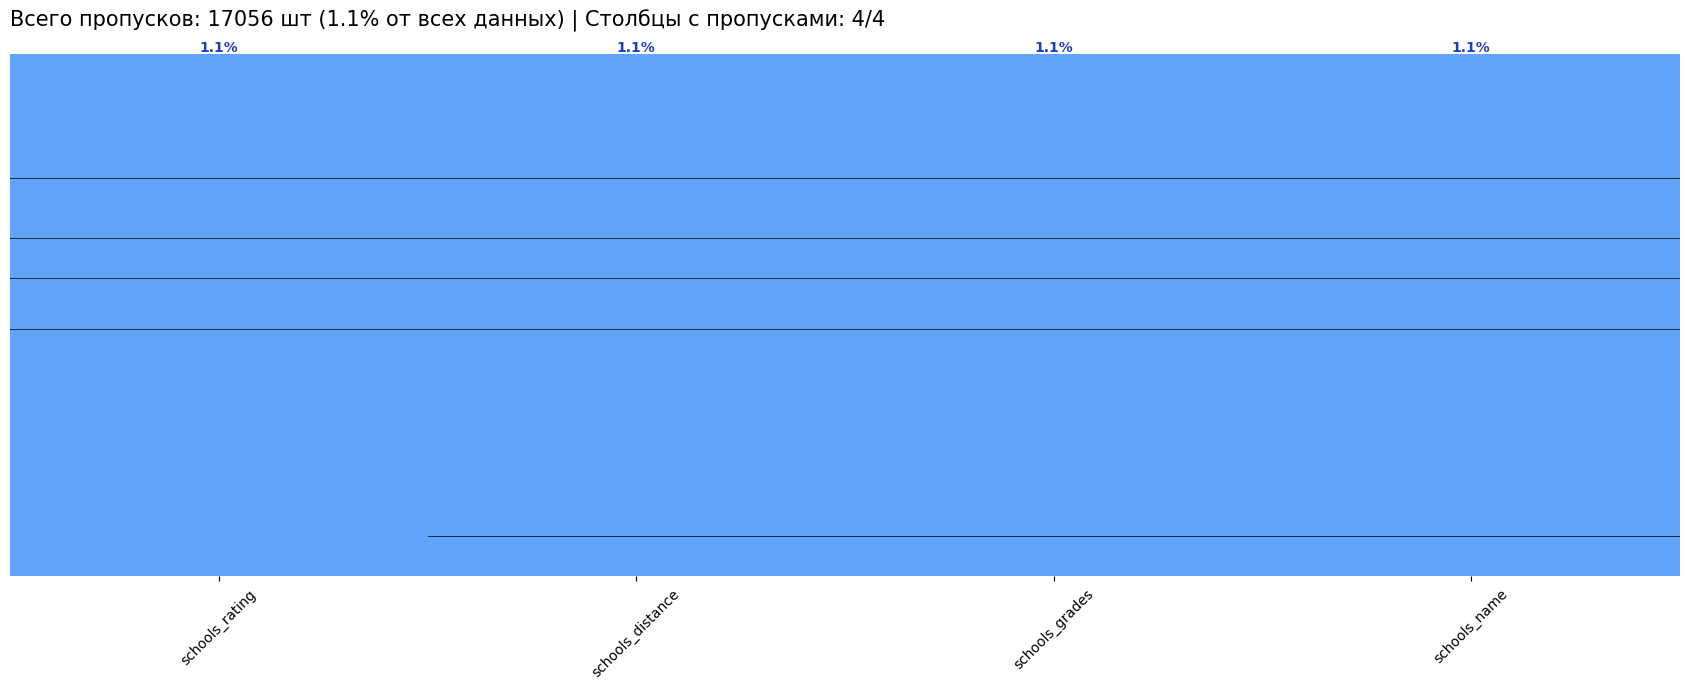

In [122]:
# проверим наши признаки на пропуски, что вышло
schools = df[['schools_rating', 'schools_distance', 'schools_grades', 'schools_name']]
graph_null(schools)

In [123]:
drop_list.extend(['schools'])

<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
    <tr>
      <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
        <div style="font-size: 20px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
          <pre style="color: black;">
Из полученных признаков можно вытащить большой объем информации, например:
- Максимальный рейтинг школ 
- Минимальный рейтинг школ 
- Средний рейтинг школ 
- Максимальная дистанция школ 
- Минимальная дистанция школ 
- Средняя дистанция школ 
- Минимальный/максимальный класс, диапазон классов 
- Наличие разных уровней образования 
- Количество школ -Тип школьной системы 
- Булевое значение начальная 
- Булевое значение средняя 
- Булевое значение старшая
На начальном этапе выделим только два признака - среднее расстояние до школы ['schools_mean_distance'] и количество школ['schools_count'].
В случае, если необходимо будет повысить качество модели, то можно будет попробовать выполнить уточнение путем увеличения количества признаков
          </pre>
        </div>
      </td>
      <td style="width: 80%; vertical-align: middle; border: none; text-align: right;">
        <img src="image/school2.jpg" alt="" style="width: 100%; max-width: 400px;">
      </td>
    </tr>
  </table>
  </ul>
</div>


In [124]:
def calculate_mean_distance(distances_list):
    """Вычисляет среднюю дистанцию из списка дистанций до школ."""
    if distances_list is None or distances_list is np.nan:
        return np.nan
    if not isinstance(distances_list, list) or len(distances_list) == 0:
        return np.nan

    try:
        numeric_distances = []
        for distance in distances_list:
            if distance is None or distance is np.nan:
                continue
            try:
                cleaned = str(distance).lower().replace('mi', '').strip()
                numeric_distance = float(cleaned)
                numeric_distances.append(numeric_distance)
            except (ValueError, TypeError):
                continue
        if numeric_distances:
            return round(np.mean(numeric_distances), 2)
        else:
            return np.nan
    except Exception:
        return np.nan

def calculate_min_distance(distances_list):
    """Вычисляет минимальную дистанцию из списка дистанций до школ."""
    if distances_list is None or distances_list is np.nan:
        return np.nan
    if not isinstance(distances_list, list) or len(distances_list) == 0:
        return np.nan

    try:
        numeric_distances = []
        for distance in distances_list:
            if distance is None or distance is np.nan:
                continue
            try:
                cleaned = str(distance).lower().replace('mi', '').strip()
                numeric_distance = float(cleaned)
                numeric_distances.append(numeric_distance)
            except (ValueError, TypeError):
                continue
        if numeric_distances:
            return round(min(numeric_distances), 2)
        else:
            return np.nan
    except Exception:
        return np.nan

# Применяем функции к DataFrame
df['schools_mean_distance'] = df['schools_distance'].apply(calculate_mean_distance)
df['schools_min_distance'] = df['schools_distance'].apply(calculate_min_distance)

In [125]:
def count_schools(schools_list):
    """
    Подсчитывает количество школ в списке
    """
    try:
        if schools_list is None or schools_list is np.nan or not isinstance(schools_list, list):
            return 0
        return len(schools_list)
    except Exception:
        return 0

df['schools_count'] = df['schools_name'].apply(count_schools)

In [126]:
drop_list.extend(['schools_rating', 'schools_distance', 'schools_grades', 'schools_name'])

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(0, 2, 112) 0%, #38cdff 30%, #7d2dff 60%, #000000 100%); border-left: 4px solid #3859ff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: #ffffffff; font-weight: 600;">target</strong>
</div>

In [127]:
analize_feature('target')

Количество уникальных показателей: 43939 шт
Количество пустых значений: 2481 шт, (0.7%)
Топ встречаемых показателей:
   1. $225,000
   2. $275,000
   3. $250,000
   4. $350,000
   5. $299,900
   6. $325,000
   7. $249,900
   8. $399,000
   9. $199,900
  10. $299,000
  11. $375,000
  12. $450,000
  13. $499,000
  14. $175,000
  15. $425,000
  16. $599,000
  17. $265,000
  18. $235,000
  19. $150,000
  20. $399,900


In [ ]:
def clean_to_number(value):
    """
    Преобразует строку, содержащую числа и спецсимволы, в числовое значение.

    Аргументы:
        Входная строка с числами и специальными символами.

    Возвращает:
        Очищенное числовое значение или None при ошибке.
    """
    if isinstance(value, str):

        value = re.sub(r'[^\d.]', '', value)


        try:
            return float(value)
        except ValueError:

            return None

    return None


In [129]:
df['target'] = df.target.apply(clean_to_number)

In [130]:
df['target'].value_counts()

225000.0    1806
275000.0    1650
250000.0    1644
350000.0    1641
325000.0    1562
            ... 
236070.0       1
752911.0       1
73360.0        1
455740.0       1
171306.0       1
Name: target, Length: 34232, dtype: int64

<div style="font-family: 'Courier New', monospace; font-size: 100%; background: linear-gradient(135deg, #dbeafe 0%, #20a2f8ff 50%, #000000ff 100%); border-left: 8px solid #60a5fa; padding: 16px; margin: 15px 0; border-radius: 12px; color: black; box-shadow: 0 0 25px rgba(37, 99, 235, 0.4), 0 0 30px rgba(96, 165, 250, 0.2);">

**Последние штрихи**

In [131]:
# Дропаем
df = df.drop(columns=drop_list)
print(f"Удалены колонки: {drop_list}")

Удалены колонки: ['status', 'propertyType', 'difference_built', 'heating', 'cooling', 'parking', 'lotsize', 'price_per_sqft', 'homeFacts', 'private pool', 'PrivatePool', 'baths', 'fireplace', 'sqft', 'beds', 'stories', 'street', 'city', 'MlsId', 'mls-id', 'schools', 'schools_rating', 'schools_distance', 'schools_grades', 'schools_name']


In [132]:
# Сохраняем
df.to_csv('data/data_clear.csv', index=False)

<div style="background: linear-gradient(135deg, #dbeafe 0%, #07376e 50%, #000000 100%); padding: 15px; border-radius: 8px; margin: 15px 0;">
  <div style="color: #000000; margin-bottom: 10px;">
    <table style="width: 100%; border: none; border-collapse: collapse;">
      <tr>
        <td style="width: 60%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 20px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
        Краткая сводка по проделанной работе:

- Проведена подготовка данных и приведение показателей признаков к единому виду;
- Распаковка вложенных структур и создание колонок: year_built, remodeled_year, heating, cooling, parking, lotsize, price_per_sqft.
- Выполнена группировка категориальных значений внутри признаков для упрощения анализа.
- Выполнено извлечение дополнительных признаков из показателя schools стандартного датафрейма [schools_mean_distance, schools_min_distance, schools_count]
- Признаки 'MlsId','mls-id' объеденены в единый, а также объеденины PrivatePool и private pool;
- Выполнен парсинг по zipcode и извлечены latitude и longitude недвижимости;



В качестве рекомендаций по начальной чистке, с целью улучшения качества дальнейшего анализа и повышения показателей будущих моделей, можно провести более точечную обработку признаков и улучшения приведения показателей к единому виду.
А также из признака mls_id имея API в Multiple Listing Service в сфере недвижимости можно спарсить дополнительную информации по недвижимости, например:
- Детальную информацию об объектах;
- Cтатус объекта;
- Историческую информацию и т.д.
      </div>
    </td>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/targ.jpg" alt="" style="width: 100%; max-width: 400px;">
    </td>
  </tr>
</table>

</div>
</div>